# Exploratory Data Analysis — HAR Datasets

This notebook performs EDA on the three multivariate time-series datasets used in the thesis:

| Dataset | Phase | Sensors | Channels | Classes | Sequence Length | Samples |
|---------|-------|---------|----------|---------|-----------------|---------|
| **BasicMotions** | 1 (UEA) | 1 wrist (acc+gyro) | 6 | 4 | 100 @ 10 Hz | 80 |
| **Epilepsy** | 1 (UEA) | 1 wrist (acc only) | 3 | 4 | 206 @ 16 Hz | 275 |
| **DSA** | 2 (UCI) | 5 body units (acc+gyro+mag) | 45 | 19 | 125 @ 25 Hz | 9 120 |

In [1]:
# ── 1. Import Required Libraries ──────────────────────────────────────────────
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, sys
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# project root
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT)
print("Project root:", ROOT)


Project root: /Users/timele23/Library/Mobile Documents/com~apple~CloudDocs/Thesis_Master


## 2. Load All Datasets

In [2]:
# ── 2. Load datasets ─────────────────────────────────────────────────────────
def load_uea(name, n_channels):
    """Load a UEA dataset (BasicMotions / Epilepsy).

    Raw .npy files are stored in NCT format (N, C, T).
    This function normalises them to NTC (N, T, C) so all downstream
    code can assume a consistent [..., timesteps, channels] layout.
    """
    base = os.path.join(ROOT, "data", "raw", name)
    def _ntc(X):
        # If stored as NCT: shape[1] == n_channels, shape[2] == timesteps
        if X.ndim == 3 and X.shape[1] == n_channels:
            return X.transpose(0, 2, 1)   # NCT → NTC
        return X
    return dict(
        X_train=_ntc(np.load(os.path.join(base, "X_train.npy"))),
        y_train=np.load(os.path.join(base, "y_train.npy")),
        X_test=_ntc(np.load(os.path.join(base, "X_test.npy"))),
        y_test=np.load(os.path.join(base, "y_test.npy")),
    )

def load_dsa():
    """Load the processed DSA dataset (already in NTC format)."""
    base = os.path.join(ROOT, "data", "processed", "DSA")
    meta_path = os.path.join(base, "metadata.json")
    meta = json.load(open(meta_path)) if os.path.exists(meta_path) else {}
    return dict(
        X=np.load(os.path.join(base, "X.npy")),
        y=np.load(os.path.join(base, "y.npy")),
        subjects=np.load(os.path.join(base, "subjects.npy")),
        metadata=meta,
    )

bm  = load_uea("BasicMotions", n_channels=6)
ep  = load_uea("Epilepsy",     n_channels=3)
dsa = load_dsa()

print("BasicMotions X_train:", bm["X_train"].shape,  "← (N, T, C)")
print("Epilepsy     X_train:", ep["X_train"].shape,  "← (N, T, C)")
print("DSA          X:      ", dsa["X"].shape,       "← (N, T, C)")


BasicMotions X_train: (40, 100, 6) ← (N, T, C)
Epilepsy     X_train: (137, 206, 3) ← (N, T, C)
DSA          X:       (9120, 125, 45) ← (N, T, C)


## 3. Preview & Data Shape

Quick look at array shapes, dtypes, and value ranges.

In [3]:
# ── 3. Dataset summary table ──────────────────────────────────────────────────
BM_CH = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
EP_CH = ["AccX", "AccY", "AccZ"]
DSA_UNITS = ["Torso", "RightArm", "LeftArm", "RightLeg", "LeftLeg"]
DSA_AXES  = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
DSA_CH    = [f"{u}_{a}" for u in DSA_UNITS for a in DSA_AXES]  # 45 channel names

rows = []
for name, d, ch in [
    ("BasicMotions", bm, BM_CH),
    ("Epilepsy", ep, EP_CH),
]:
    X = np.concatenate([d["X_train"], d["X_test"]])
    y = np.concatenate([d["y_train"], d["y_test"]])
    rows.append(dict(
        Dataset=name,
        Samples=X.shape[0],
        Train=d["X_train"].shape[0],
        Test=d["X_test"].shape[0],
        Timesteps=X.shape[1],
        Channels=X.shape[2],
        Classes=len(np.unique(y)),
        dtype=str(X.dtype),
        Min=f"{X.min():.3f}",
        Max=f"{X.max():.3f}",
        Mean=f"{X.mean():.3f}",
        Std=f"{X.std():.3f}",
        NaN=int(np.isnan(X).sum()),
    ))

X_dsa = dsa["X"]
rows.append(dict(
    Dataset="DSA",
    Samples=X_dsa.shape[0],
    Train="LOSO-CV",
    Test="LOSO-CV",
    Timesteps=X_dsa.shape[1],
    Channels=X_dsa.shape[2],
    Classes=len(np.unique(dsa["y"])),
    dtype=str(X_dsa.dtype),
    Min=f"{X_dsa.min():.3f}",
    Max=f"{X_dsa.max():.3f}",
    Mean=f"{X_dsa.mean():.3f}",
    Std=f"{X_dsa.std():.3f}",
    NaN=int(np.isnan(X_dsa).sum()),
))

summary_df = pd.DataFrame(rows)
summary_df

,Dataset,Samples,Train,Test,Timesteps,Channels,Classes,dtype,Min,Max,Mean,Std,NaN
0,BasicMotions,80,40,40,100,6,4,float32,-27.822,34.866,0.008,4.666,0
1,Epilepsy,275,137,138,206,3,4,float32,-3.590,3.590,-0.143,0.881,0
2,DSA,9120,LOSO-CV,LOSO-CV,125,45,19,float32,-119.810,120.530,0.181,3.852,0


## 4. Check for Missing Values & Duplicates

In [4]:
# ── 4. Missing values & duplicates ───────────────────────────────────────────
for name, X in [("BasicMotions", np.concatenate([bm["X_train"], bm["X_test"]])),
                ("Epilepsy", np.concatenate([ep["X_train"], ep["X_test"]])),
                ("DSA", dsa["X"])]:
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    # check for duplicate samples (flatten each sample then compare)
    flat = X.reshape(X.shape[0], -1)
    n_dup = flat.shape[0] - np.unique(flat, axis=0).shape[0]
    print(f"{name:15s} | NaN: {nan_count:,}  Inf: {inf_count:,}  "
          f"Duplicate samples: {n_dup}/{X.shape[0]}")

BasicMotions    | NaN: 0  Inf: 0  Duplicate samples: 0/80
Epilepsy        | NaN: 0  Inf: 0  Duplicate samples: 1/275


DSA             | NaN: 0  Inf: 0  Duplicate samples: 0/9120


## 5. Class Distribution

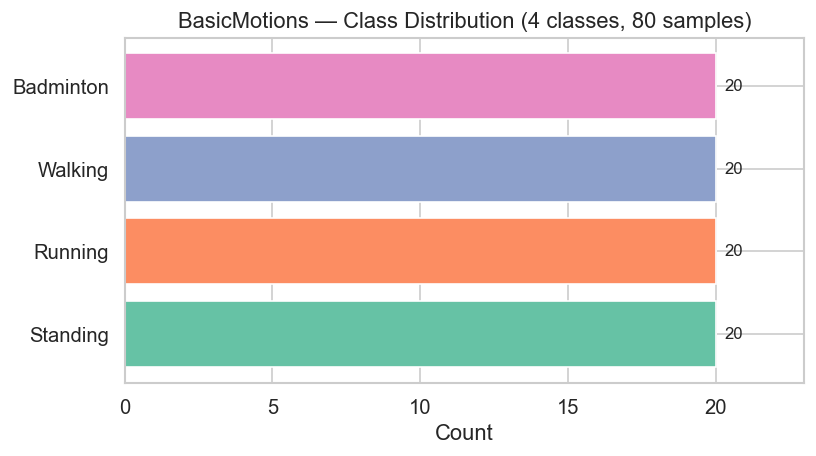

In [5]:
# ── 5a. Shared label definitions ─────────────────────────────────────────────
y_bm = np.concatenate([bm["y_train"], bm["y_test"]])
y_ep = np.concatenate([ep["y_train"], ep["y_test"]])
y_dsa = dsa["y"]

DSA_ACTIVITIES = [
    "sitting", "standing", "lying_back", "lying_right",
    "ascending_stairs", "descending_stairs",
    "standing_elevator", "moving_elevator",
    "walking_parking", "walking_treadmill_flat",
    "walking_treadmill_incline", "running_treadmill",
    "exercising_stepper", "exercising_cross_trainer",
    "cycling_horizontal", "cycling_vertical",
    "rowing", "jumping", "basketball",
]

# ── 5b. BasicMotions class distribution ──────────────────────────────────────
cts = Counter(y_bm)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(cts.keys()), list(cts.values()),
        color=sns.color_palette("Set2", len(cts)))
for bar, v in zip(ax.patches, cts.values()):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontsize=10)
ax.set_title("BasicMotions — Class Distribution (4 classes, 80 samples)")
ax.set_xlabel("Count")
ax.set_xlim(0, max(cts.values()) * 1.15)
plt.tight_layout()
plt.show()


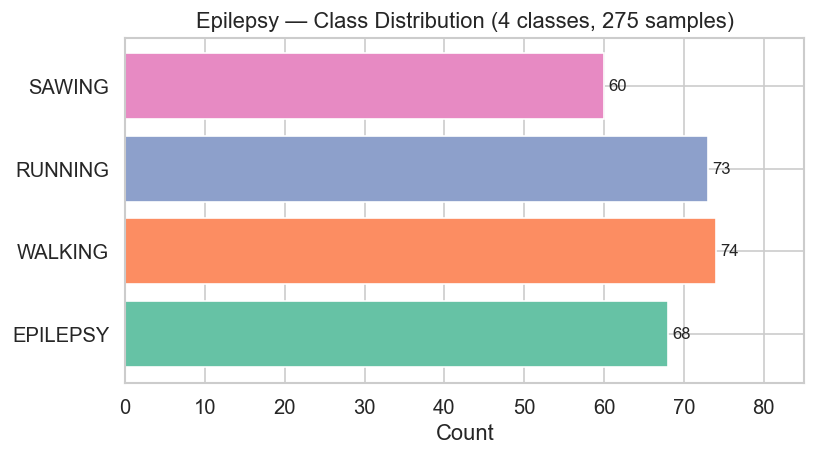

In [6]:
# ── 5c. Epilepsy class distribution ──────────────────────────────────────────
cts = Counter(y_ep)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(cts.keys()), list(cts.values()),
        color=sns.color_palette("Set2", len(cts)))
for bar, v in zip(ax.patches, cts.values()):
    ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontsize=10)
ax.set_title("Epilepsy — Class Distribution (4 classes, 275 samples)")
ax.set_xlabel("Count")
ax.set_xlim(0, max(cts.values()) * 1.15)
plt.tight_layout()
plt.show()


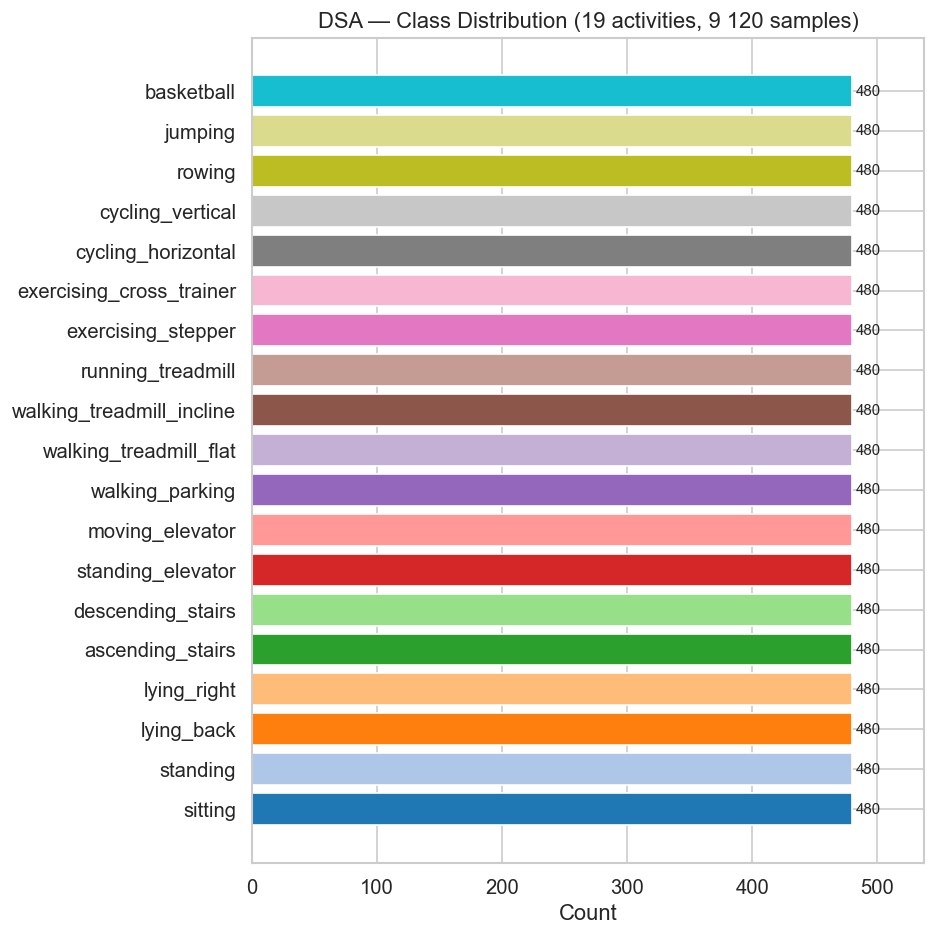

In [7]:
# ── 5d. DSA class distribution ───────────────────────────────────────────────
cts_dsa = Counter(y_dsa)
labels = [DSA_ACTIVITIES[i] for i in sorted(cts_dsa.keys())]
vals   = [cts_dsa[k] for k in sorted(cts_dsa.keys())]

fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(labels, vals, color=sns.color_palette("tab20", 19))
for bar, v in zip(bars, vals):
    ax.text(v + 3, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontsize=9)
ax.set_title("DSA — Class Distribution (19 activities, 9 120 samples)")
ax.set_xlabel("Count")
ax.set_xlim(0, max(vals) * 1.12)
plt.tight_layout()
plt.show()


## 6. Summary Statistics — Per-Channel Distributions

Box-and-whisker plots showing the value distribution of each sensor channel (aggregated across all timesteps).

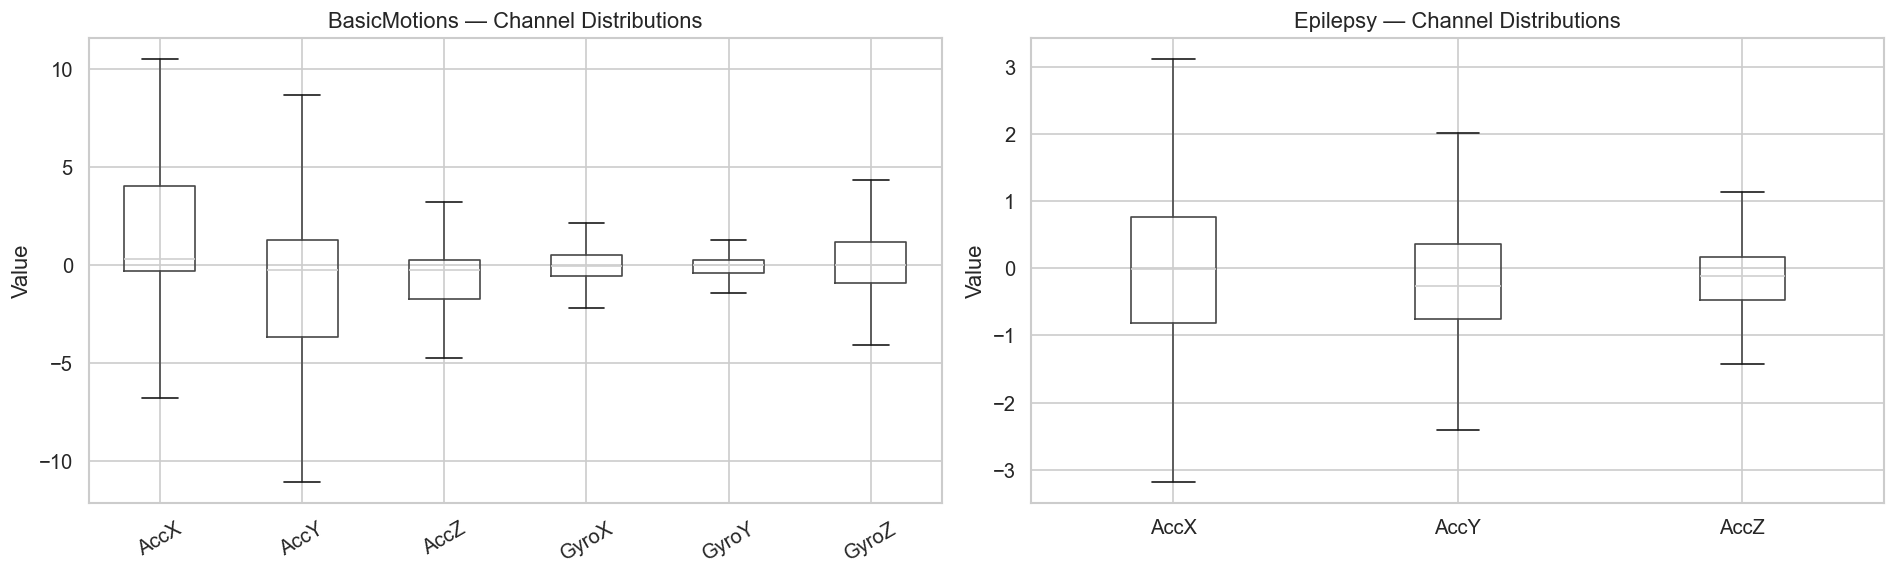

BasicMotions — per-channel stats:
           AccX      AccY      AccZ     GyroX     GyroY     GyroZ
count  8000.000  8000.000  8000.000  8000.000  8000.000  8000.000
mean      2.459    -1.342    -1.038    -0.000    -0.005    -0.028
std       6.832     6.715     3.387     2.003     1.696     3.406
min     -22.462   -27.822   -25.234   -18.969   -21.115   -24.516
25%      -0.283    -3.655    -1.730    -0.557    -0.386    -0.919
50%       0.310    -0.227    -0.214    -0.011    -0.008     0.040
75%       4.044     1.274     0.253     0.538     0.290     1.185
max      29.394    24.805    19.793    34.866    18.212    13.948

Epilepsy — per-channel stats:
            AccX       AccY       AccZ
count  56650.000  56650.000  56650.000
mean      -0.039     -0.260     -0.129
std        1.010      1.012      0.508
min       -3.590     -3.590     -2.190
25%       -0.820     -0.750     -0.470
50%       -0.010     -0.270     -0.110
75%        0.760      0.360      0.170
max        3.590      3.590  

In [8]:
# ── 6a. Per-channel boxplots — BasicMotions & Epilepsy ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BasicMotions: flatten (N,T,C) → (N*T, C)
X_bm = np.concatenate([bm["X_train"], bm["X_test"]])  # (80, 100, 6)
df_bm = pd.DataFrame(X_bm.reshape(-1, 6), columns=BM_CH)
df_bm.boxplot(ax=axes[0], vert=True, showfliers=False)
axes[0].set_title("BasicMotions — Channel Distributions")
axes[0].set_ylabel("Value")
axes[0].tick_params(axis="x", rotation=30)

# Epilepsy
X_ep = np.concatenate([ep["X_train"], ep["X_test"]])  # (275, 206, 3)
df_ep = pd.DataFrame(X_ep.reshape(-1, 3), columns=EP_CH)
df_ep.boxplot(ax=axes[1], vert=True, showfliers=False)
axes[1].set_title("Epilepsy — Channel Distributions")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Numeric summary
print("BasicMotions — per-channel stats:")
print(df_bm.describe().round(3).to_string())
print("\nEpilepsy — per-channel stats:")
print(df_ep.describe().round(3).to_string())

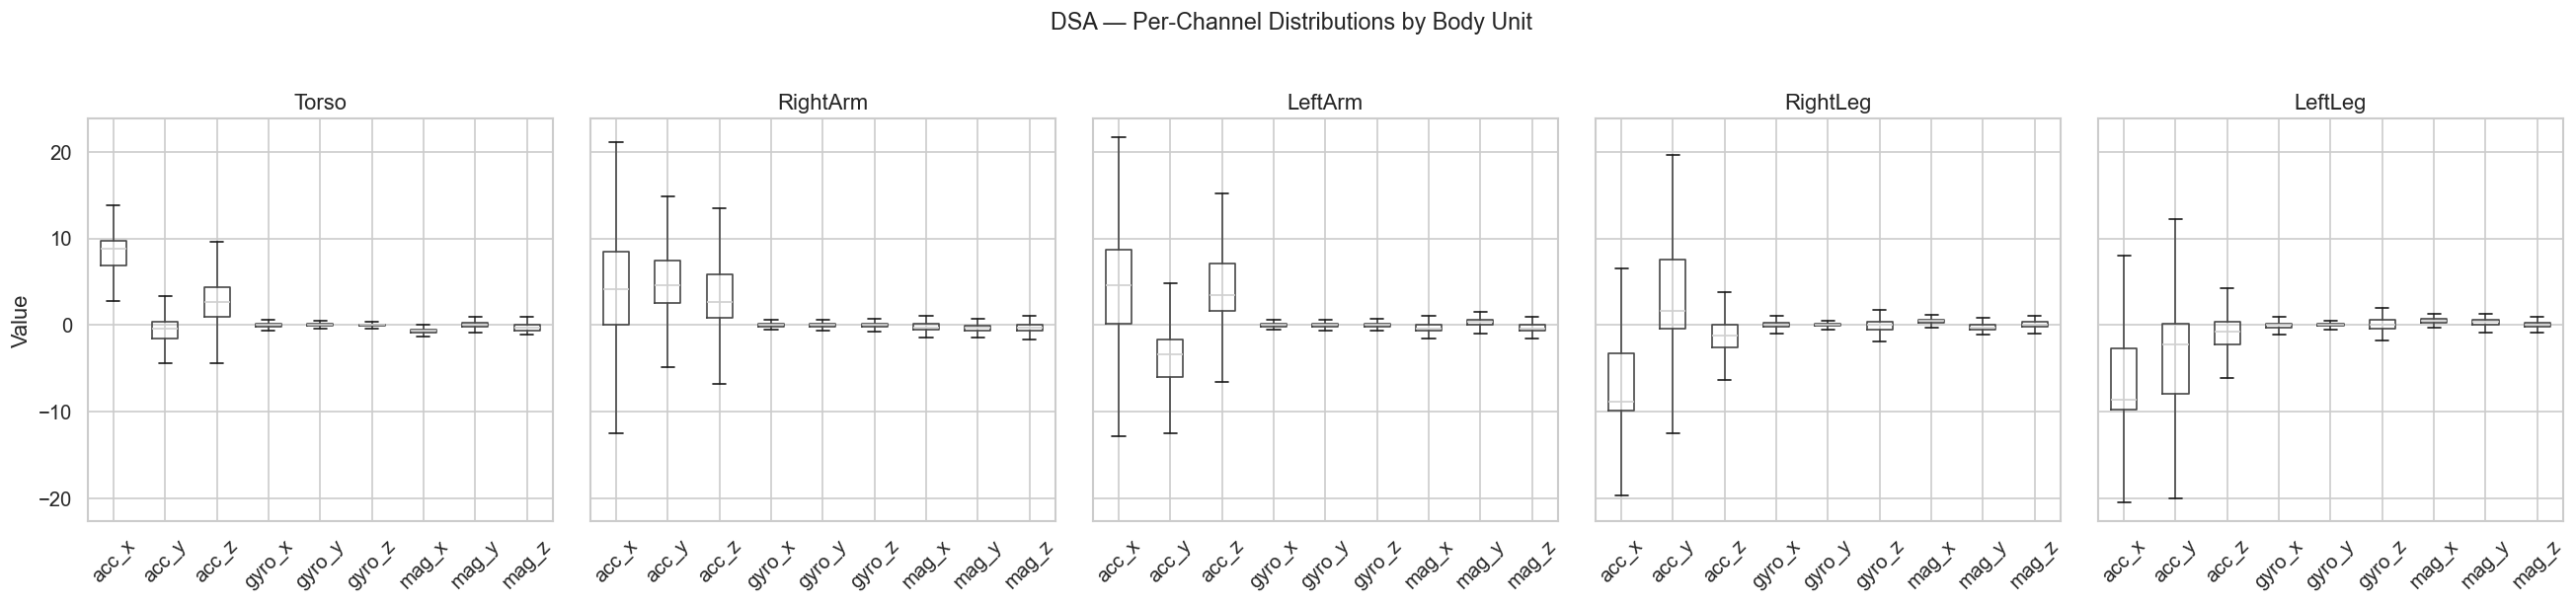

In [9]:
# ── 6b. Per-channel boxplots — DSA (grouped by body unit) ────────────────────
X_dsa = dsa["X"]  # (9120, 125, 45)
flat_dsa = X_dsa.reshape(-1, 45)  # (9120*125, 45)

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
for i, unit in enumerate(DSA_UNITS):
    cols = DSA_CH[i*9:(i+1)*9]
    short = [c.split("_", 1)[1] for c in cols]  # remove unit prefix
    df_unit = pd.DataFrame(flat_dsa[:, i*9:(i+1)*9], columns=short)
    df_unit.boxplot(ax=axes[i], vert=True, showfliers=False)
    axes[i].set_title(unit)
    axes[i].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Value")
fig.suptitle("DSA — Per-Channel Distributions by Body Unit", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Sample Time Series — One Example per Class

Visualise raw sensor traces for each activity class to build intuition about what the models will learn.

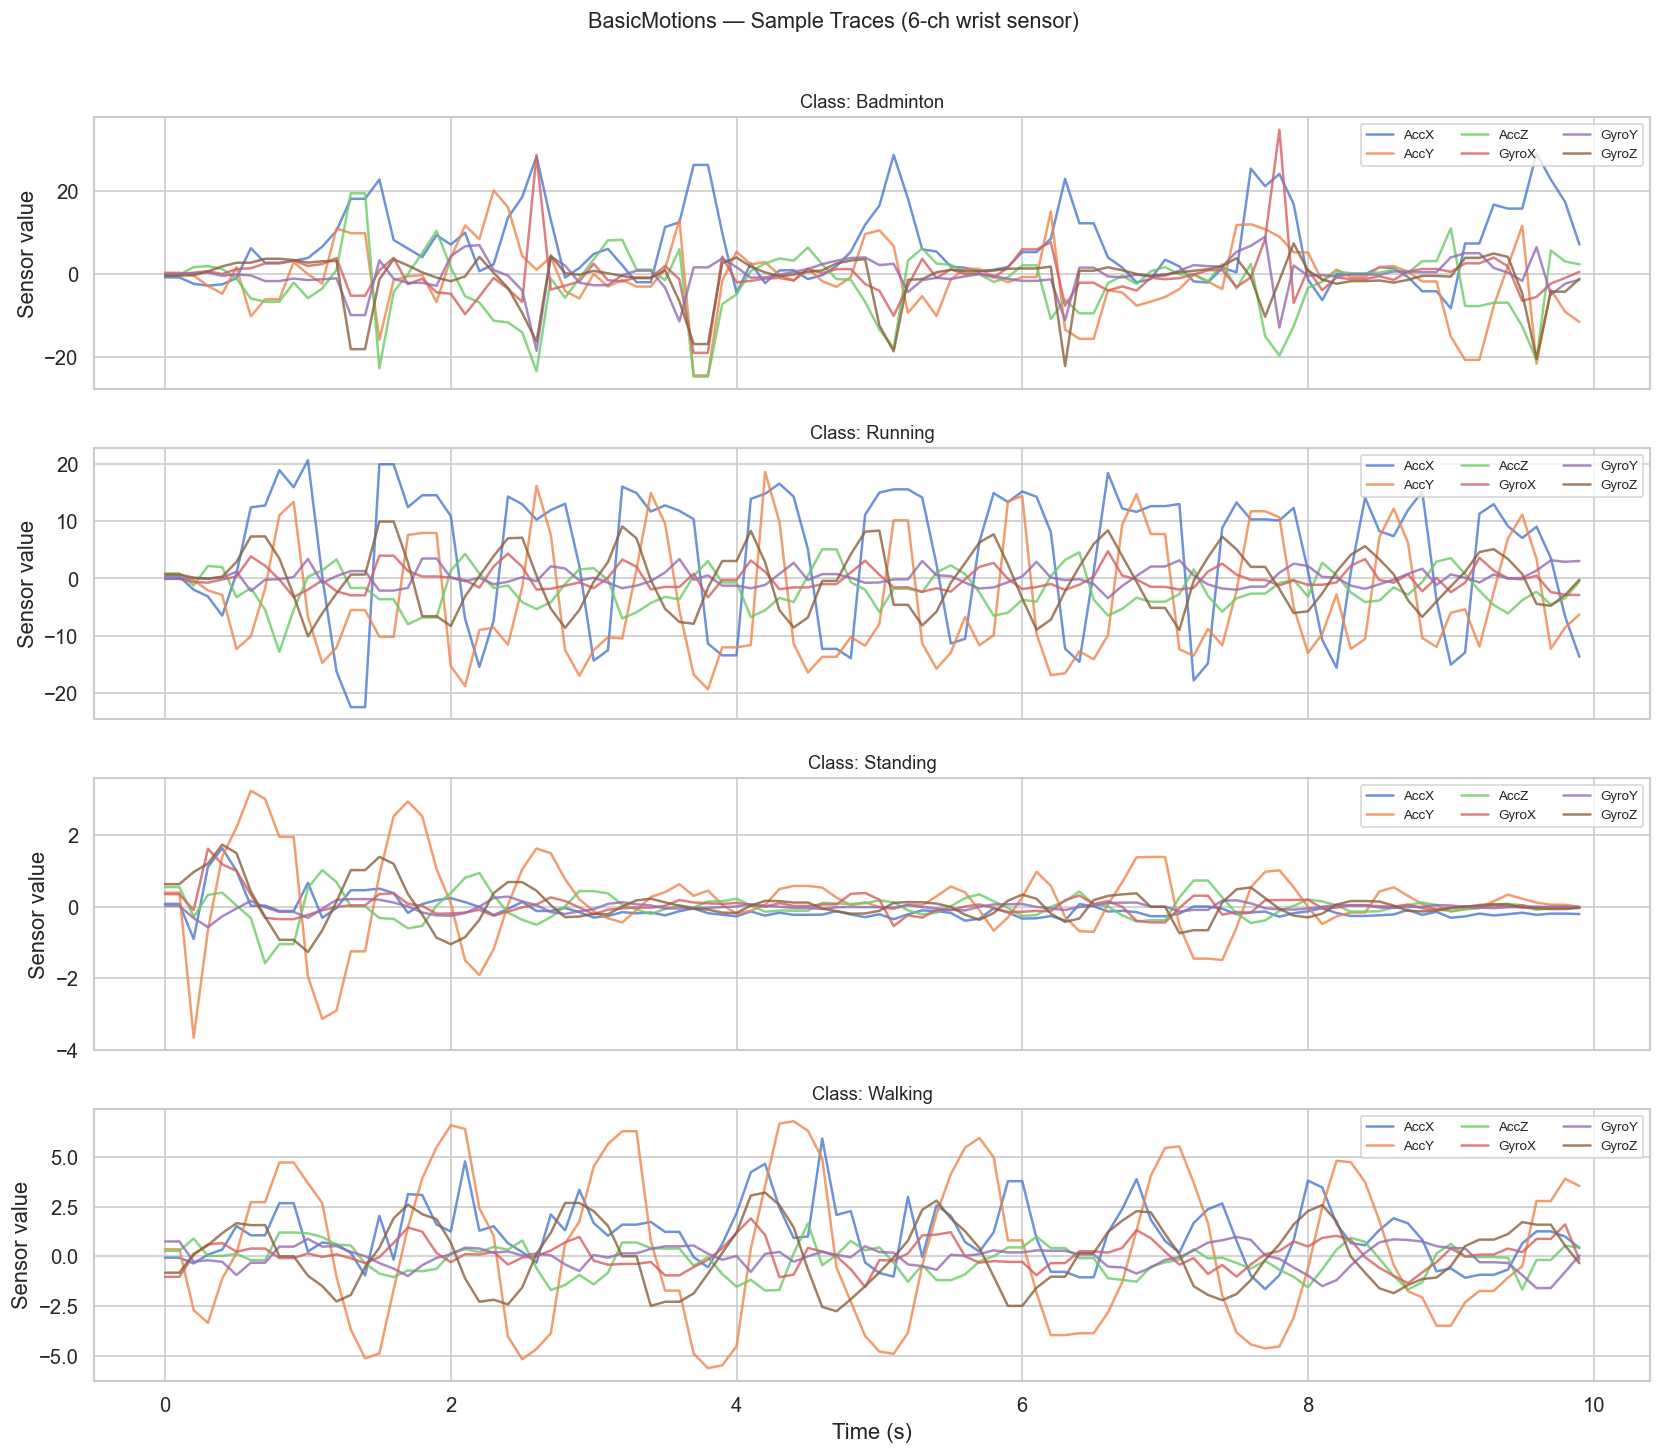

In [10]:
# ── 7a. BasicMotions — one sample per class ───────────────────────────────────
classes_bm = np.unique(y_bm)
fig, axes = plt.subplots(len(classes_bm), 1, figsize=(14, 3 * len(classes_bm)), sharex=True)

for i, cls in enumerate(classes_bm):
    idx = np.where(y_bm == cls)[0][0]
    sample = X_bm[idx]  # (100, 6)
    t = np.arange(sample.shape[0]) / 10.0  # 10 Hz → seconds
    for ch in range(6):
        axes[i].plot(t, sample[:, ch], label=BM_CH[ch], alpha=0.8)
    axes[i].set_title(f"Class: {cls}", fontsize=11)
    axes[i].set_ylabel("Sensor value")
    axes[i].legend(loc="upper right", fontsize=8, ncol=3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("BasicMotions — Sample Traces (6-ch wrist sensor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

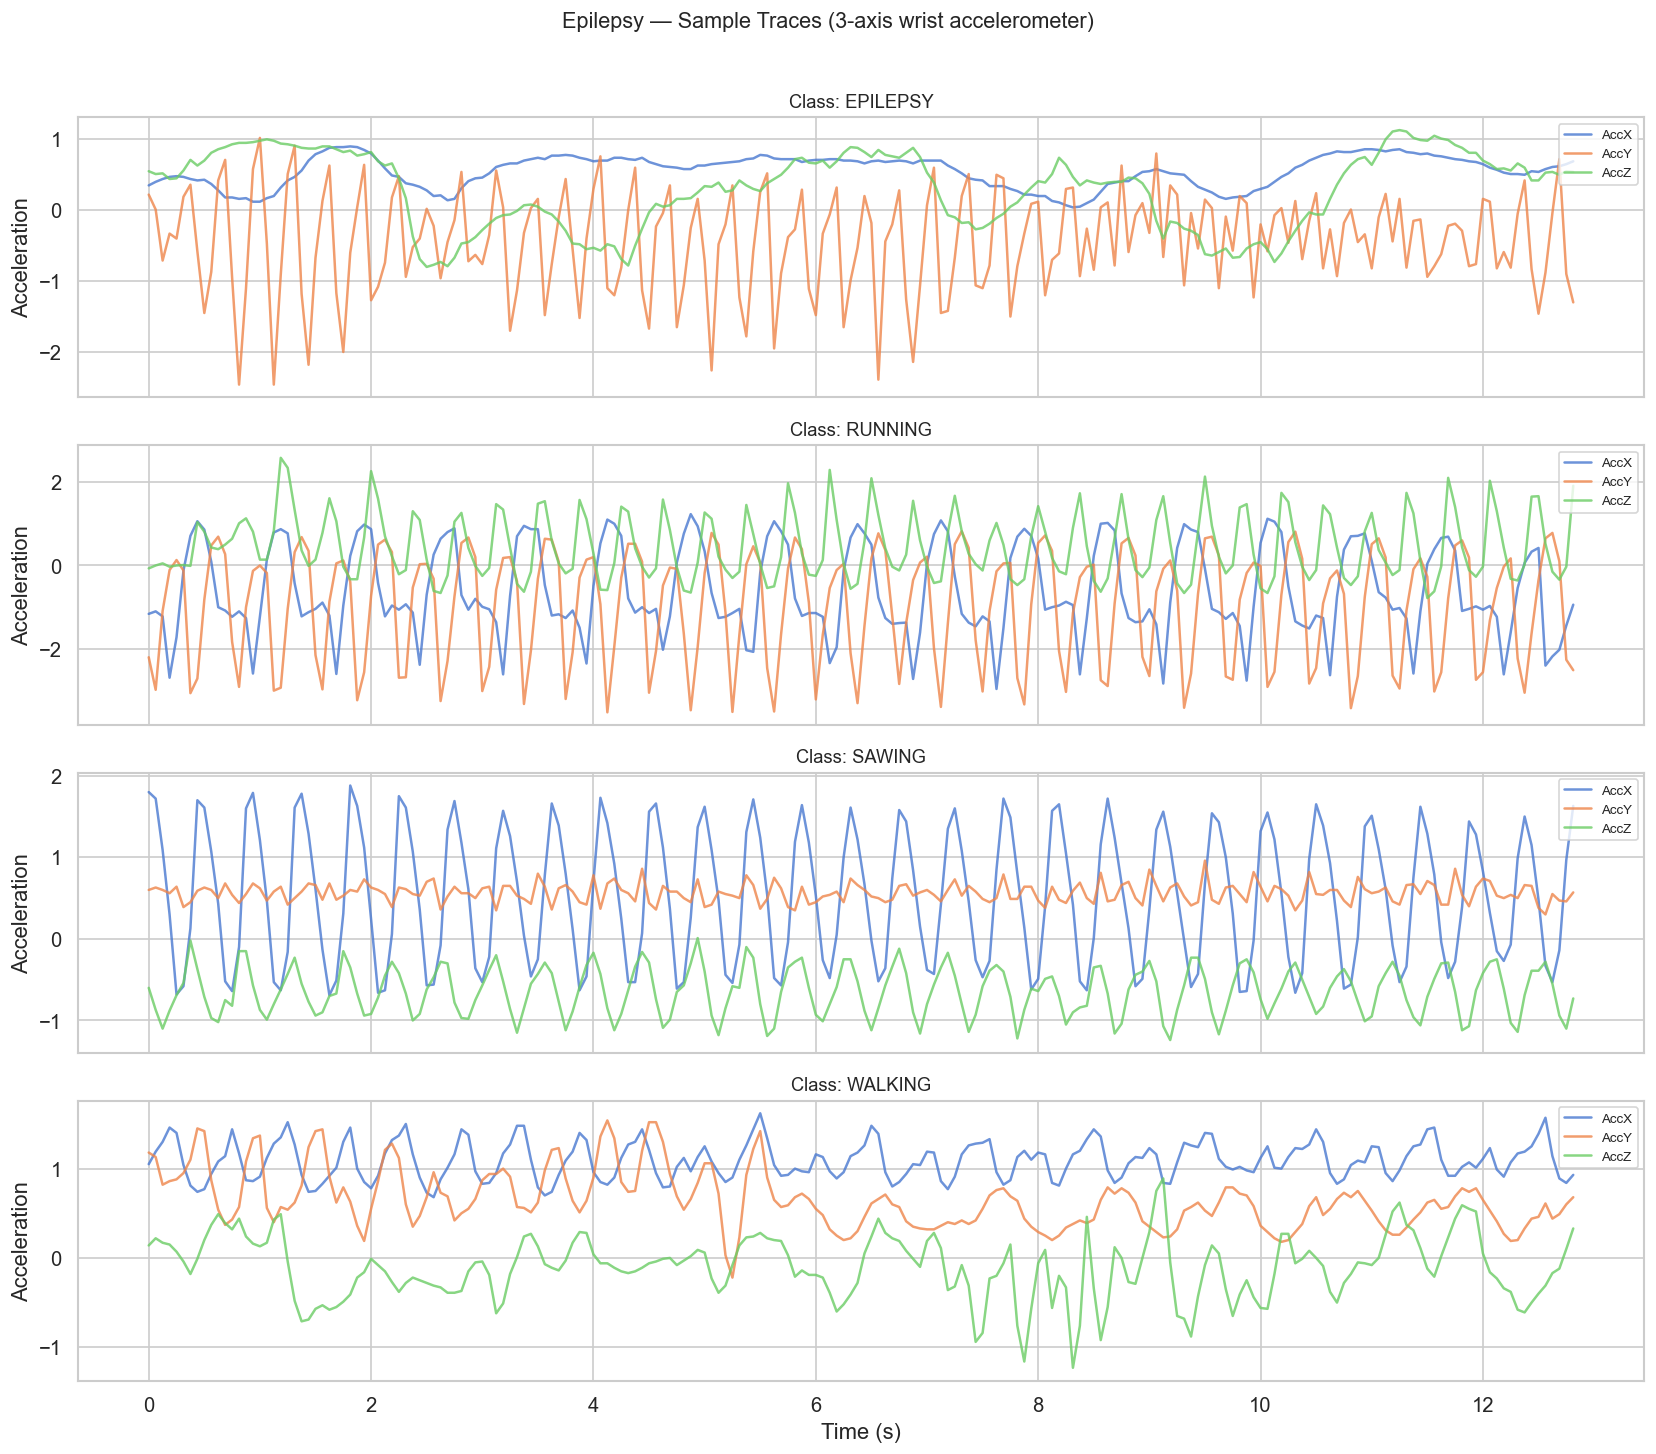

In [11]:
# ── 7b. Epilepsy — one sample per class ───────────────────────────────────────
classes_ep = np.unique(y_ep)
fig, axes = plt.subplots(len(classes_ep), 1, figsize=(14, 3 * len(classes_ep)), sharex=True)

for i, cls in enumerate(classes_ep):
    idx = np.where(y_ep == cls)[0][0]
    sample = X_ep[idx]  # (206, 3)
    t = np.arange(sample.shape[0]) / 16.0  # 16 Hz → seconds
    for ch in range(3):
        axes[i].plot(t, sample[:, ch], label=EP_CH[ch], alpha=0.8)
    axes[i].set_title(f"Class: {cls}", fontsize=11)
    axes[i].set_ylabel("Acceleration")
    axes[i].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Epilepsy — Sample Traces (3-axis wrist accelerometer)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

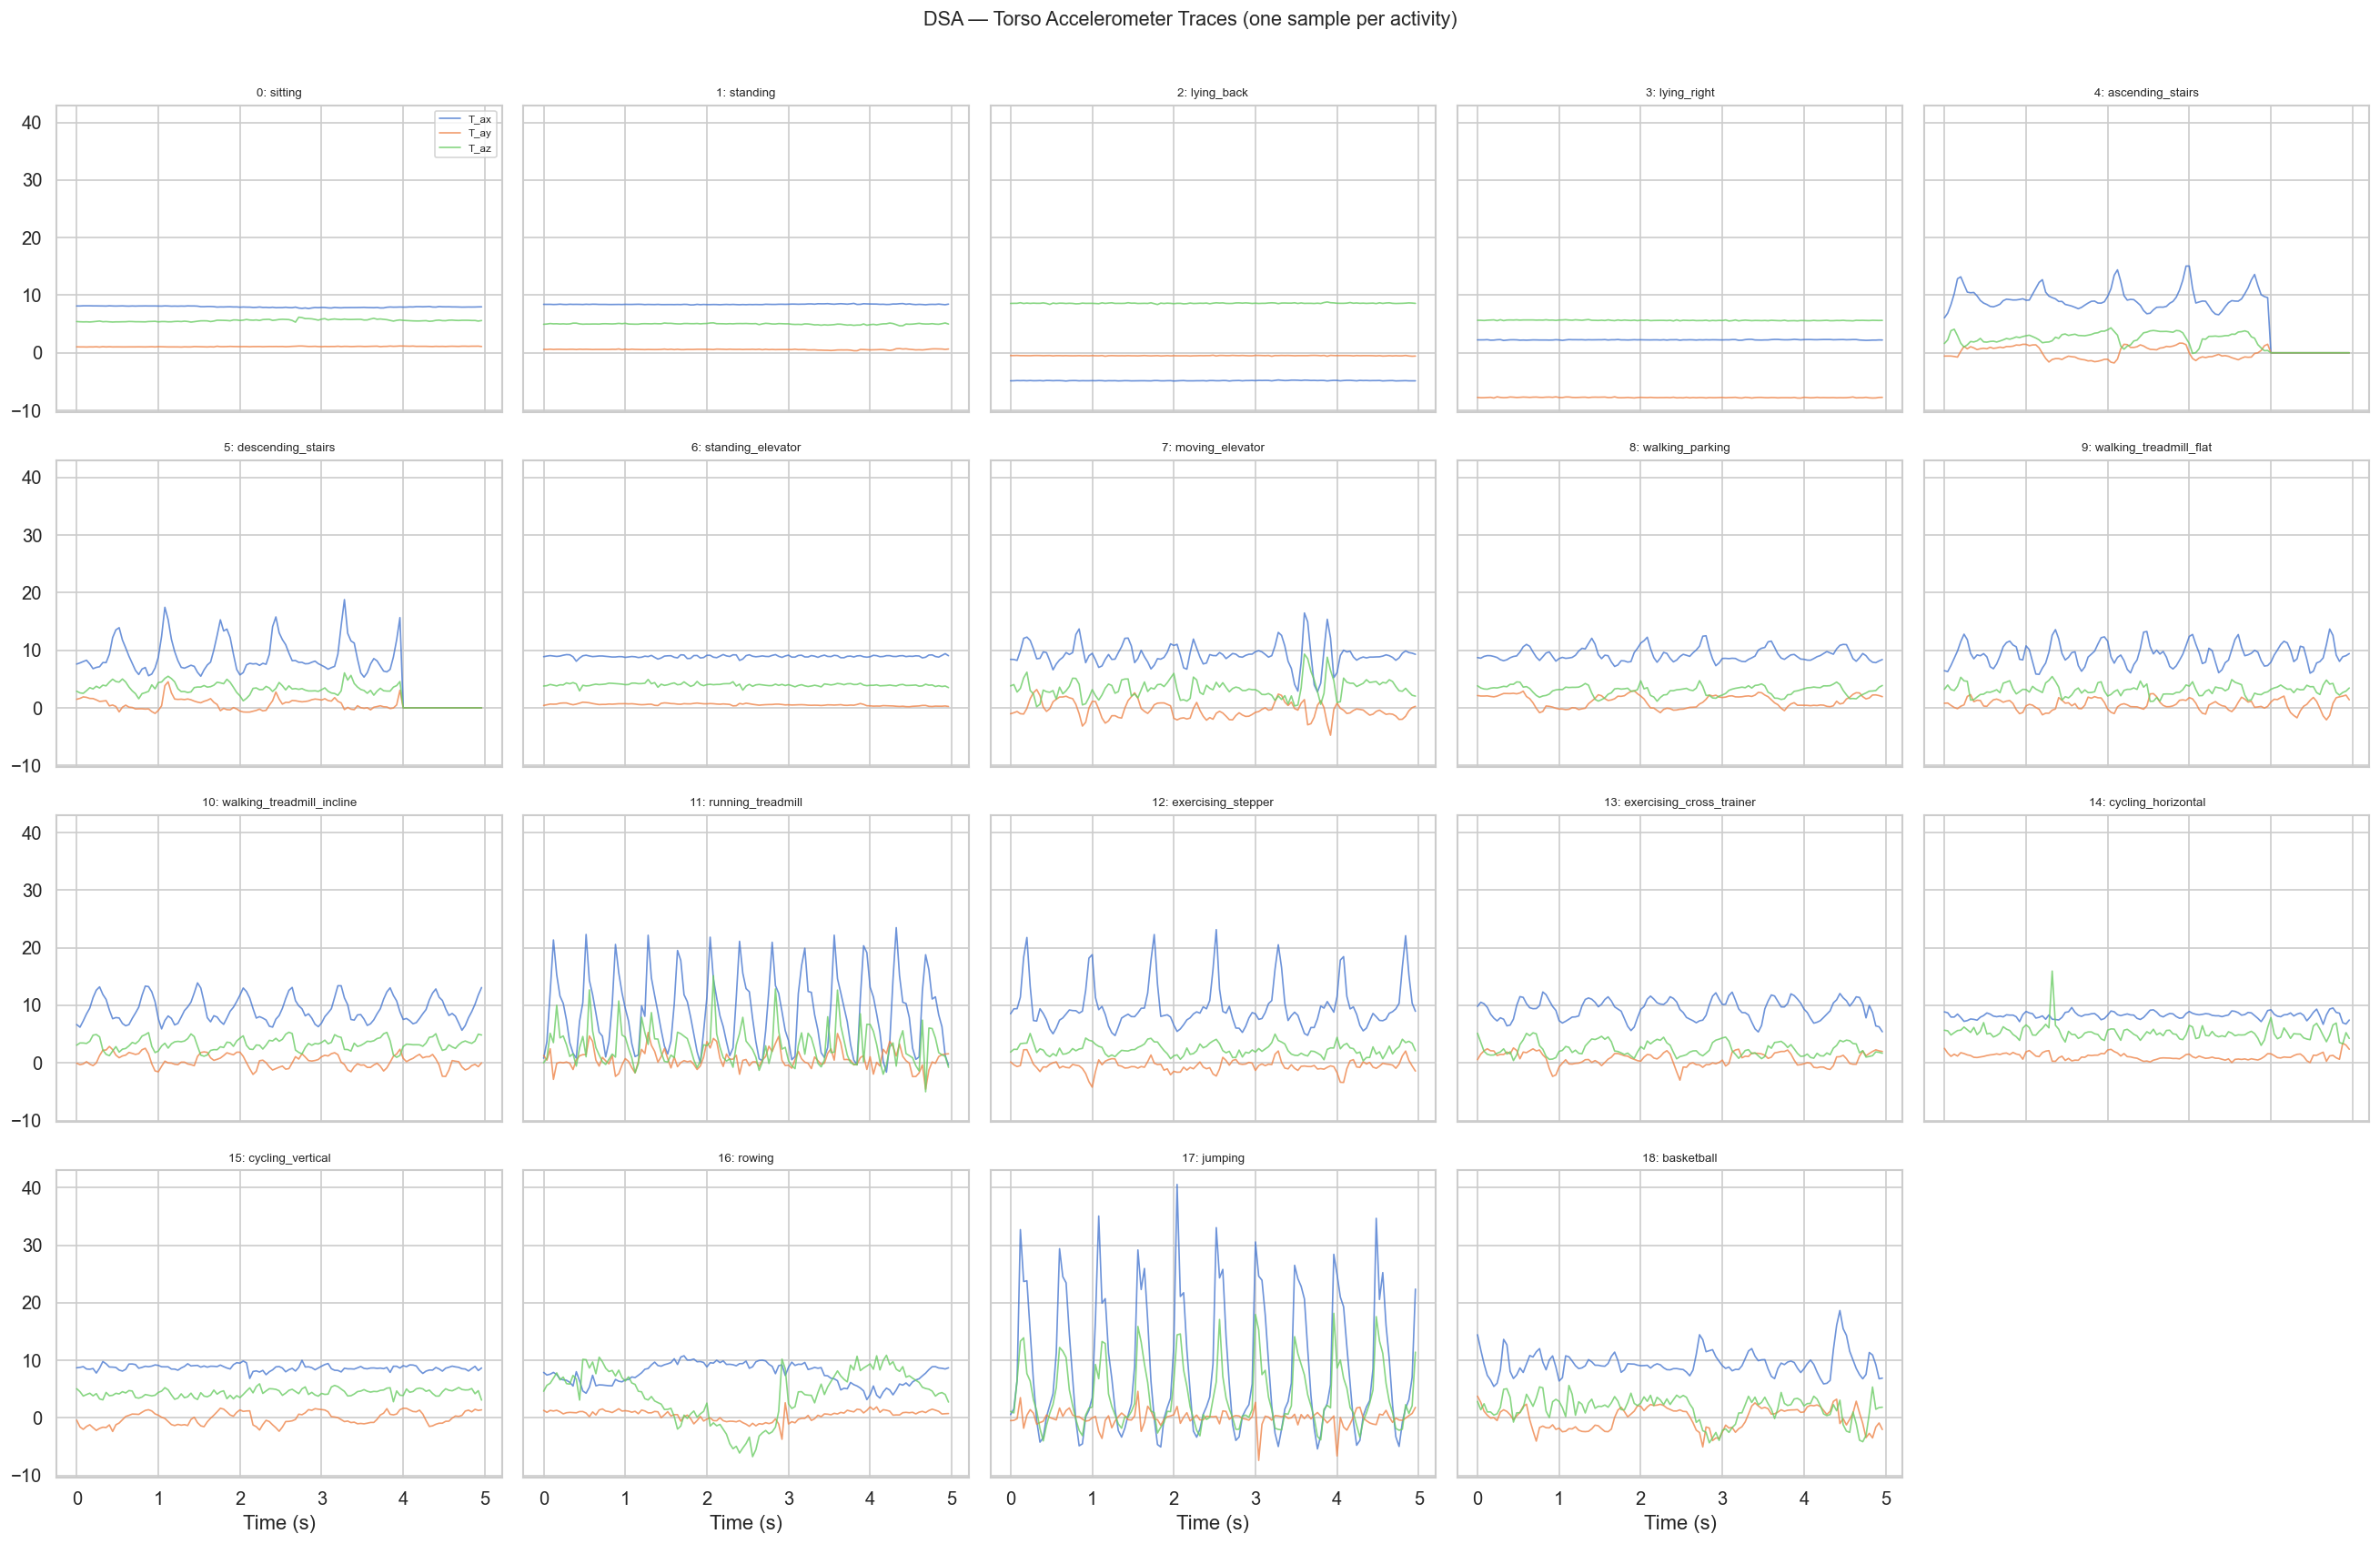

In [12]:
# ── 7c. DSA — one sample per activity (torso accelerometer only for clarity) ──
X_dsa = dsa["X"]
y_dsa = dsa["y"]
classes_dsa = sorted(np.unique(y_dsa))

fig, axes = plt.subplots(4, 5, figsize=(22, 14), sharex=True, sharey=True)
axes = axes.flatten()

# Show torso acc_x / acc_y / acc_z (first 3 channels)
for i, cls in enumerate(classes_dsa):
    ax = axes[i]
    idx = np.where(y_dsa == cls)[0][0]
    sample = X_dsa[idx]  # (125, 45)
    t = np.arange(125) / 25.0  # 25 Hz → seconds
    for ch, label in enumerate(["T_ax", "T_ay", "T_az"]):
        ax.plot(t, sample[:, ch], label=label, alpha=0.8, linewidth=1)
    title = DSA_ACTIVITIES[cls] if cls < len(DSA_ACTIVITIES) else str(cls)
    ax.set_title(f"{cls}: {title}", fontsize=8)
    if i >= 15:
        ax.set_xlabel("Time (s)")

# hide last empty axis
axes[-1].set_visible(False)
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("DSA — Torso Accelerometer Traces (one sample per activity)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Inter-channel correlation heatmaps. High correlation between channels tells us about redundancy; it also informs whether graph edges between sensor nodes are justified.

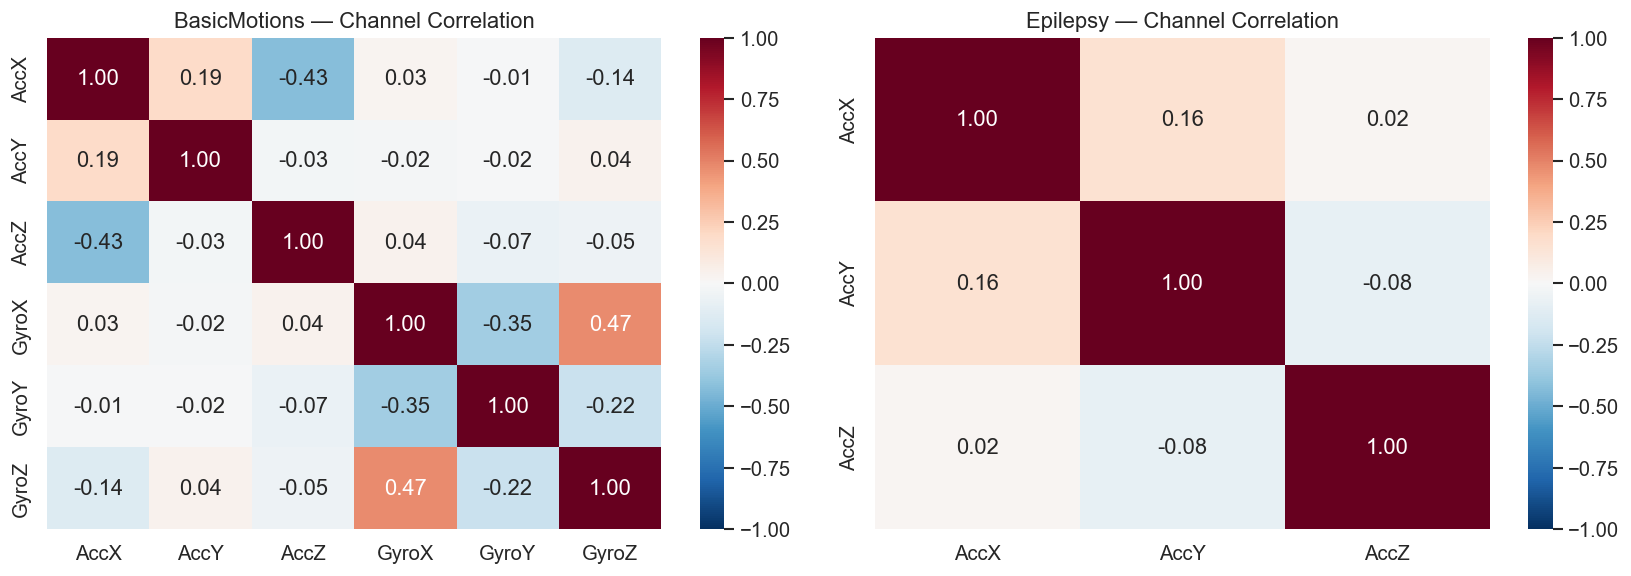

In [13]:
# ── 8a. Correlation heatmaps — BasicMotions & Epilepsy ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BasicMotions (6 channels)
corr_bm = np.corrcoef(X_bm.reshape(-1, 6).T)
sns.heatmap(corr_bm, ax=axes[0], annot=True, fmt=".2f", cmap="RdBu_r",
            xticklabels=BM_CH, yticklabels=BM_CH, vmin=-1, vmax=1, center=0)
axes[0].set_title("BasicMotions — Channel Correlation")

# Epilepsy (3 channels)
corr_ep = np.corrcoef(X_ep.reshape(-1, 3).T)
sns.heatmap(corr_ep, ax=axes[1], annot=True, fmt=".2f", cmap="RdBu_r",
            xticklabels=EP_CH, yticklabels=EP_CH, vmin=-1, vmax=1, center=0)
axes[1].set_title("Epilepsy — Channel Correlation")

plt.tight_layout()
plt.show()

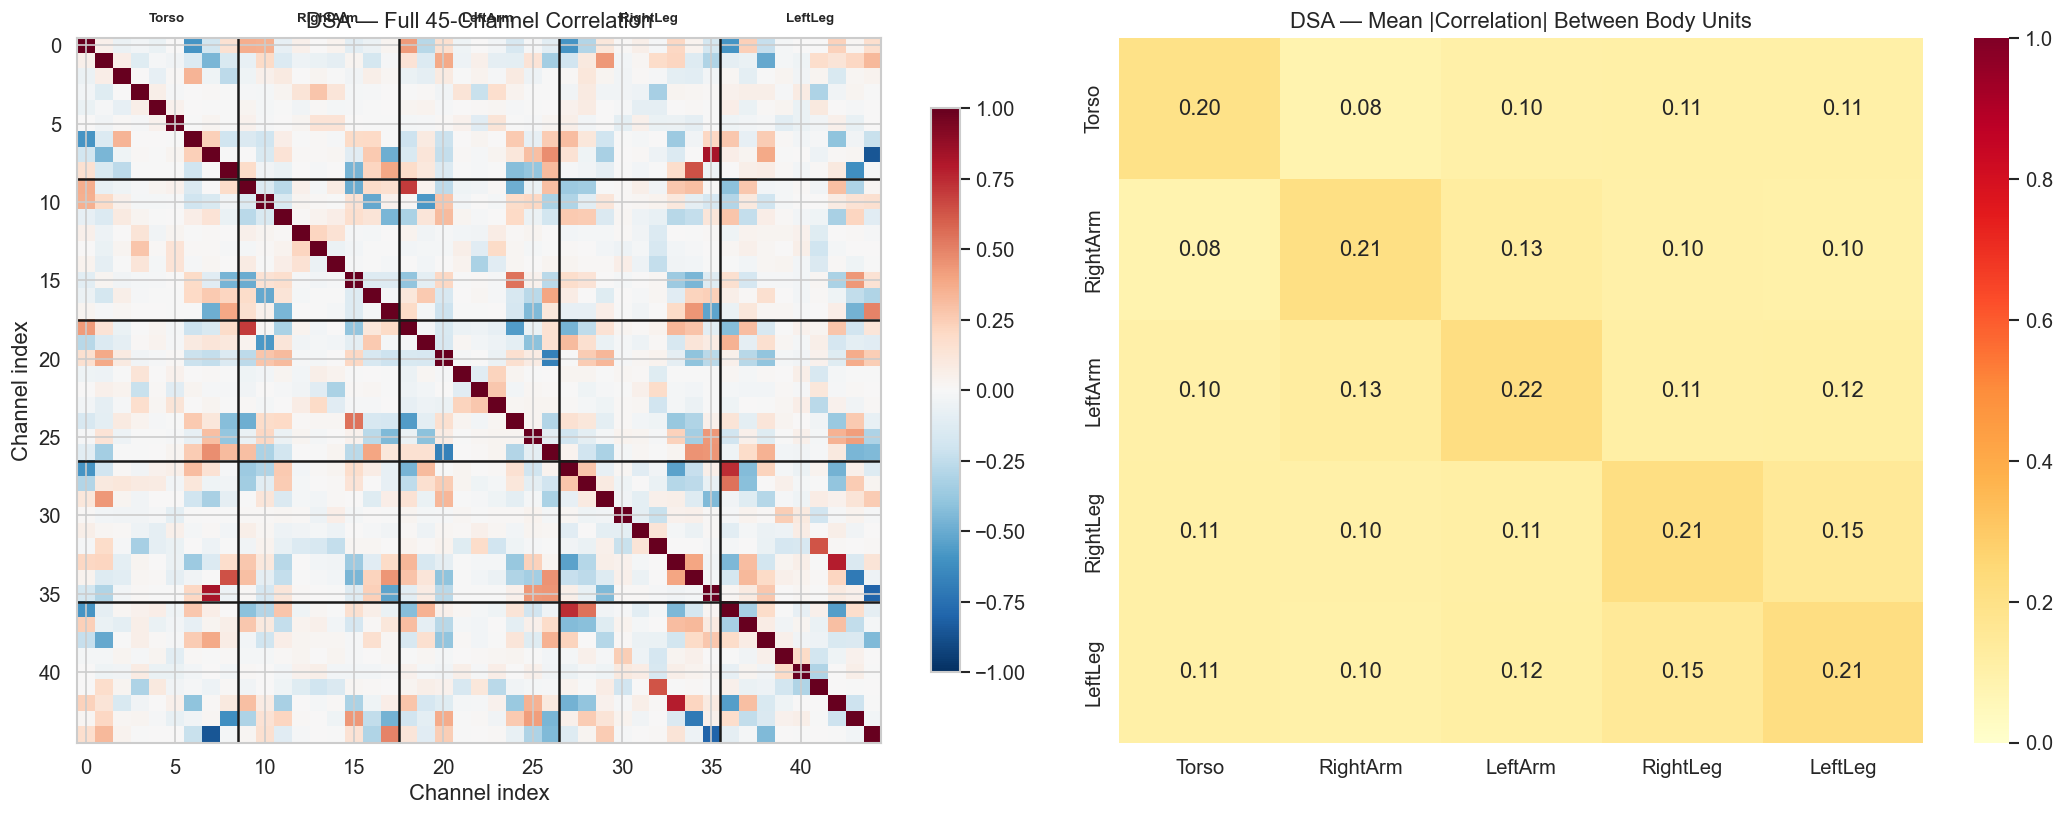

In [14]:
# ── 8b. DSA correlation — full 45×45 and body-unit block structure ────────────
corr_dsa = np.corrcoef(X_dsa.reshape(-1, 45).T)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full 45×45
im = axes[0].imshow(corr_dsa, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
# Draw unit boundaries
for b in [9, 18, 27, 36]:
    axes[0].axhline(b - 0.5, color="k", linewidth=1.5)
    axes[0].axvline(b - 0.5, color="k", linewidth=1.5)
axes[0].set_title("DSA — Full 45-Channel Correlation")
axes[0].set_xlabel("Channel index")
axes[0].set_ylabel("Channel index")
# label unit blocks
for i, u in enumerate(DSA_UNITS):
    axes[0].text(i * 9 + 4.5, -1.5, u, ha="center", fontsize=8, fontweight="bold")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Coarse 5×5: mean absolute correlation between body units
coarse = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        block = corr_dsa[i*9:(i+1)*9, j*9:(j+1)*9]
        coarse[i, j] = np.mean(np.abs(block))
sns.heatmap(coarse, ax=axes[1], annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=DSA_UNITS, yticklabels=DSA_UNITS, vmin=0, vmax=1)
axes[1].set_title("DSA — Mean |Correlation| Between Body Units")

plt.tight_layout()
plt.show()

## 9. Outlier Detection — Box Plots & IQR

Check whether there are extreme values or heavy-tailed distributions across channels.

In [15]:
# ── 9. Outlier summary (IQR method) ──────────────────────────────────────────
def outlier_report(X, ch_names, dataset_name):
    """Report per-channel outlier % using 1.5×IQR rule."""
    flat = X.reshape(-1, X.shape[-1])
    rows = []
    for c in range(flat.shape[1]):
        vals = flat[:, c]
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((vals < lo) | (vals > hi)).sum())
        rows.append(dict(
            channel=ch_names[c] if c < len(ch_names) else f"ch{c}",
            outlier_count=n_out,
            outlier_pct=round(100 * n_out / len(vals), 2),
            min=round(float(vals.min()), 3),
            max=round(float(vals.max()), 3),
        ))
    df = pd.DataFrame(rows)
    print(f"\n{dataset_name} — Outlier Summary (1.5×IQR)")
    print(f"  Total data points per channel: {flat.shape[0]:,}")
    print(f"  Channels with >5% outliers: {(df['outlier_pct'] > 5).sum()}/{len(df)}")
    return df

out_bm = outlier_report(X_bm, BM_CH, "BasicMotions")
out_ep = outlier_report(X_ep, EP_CH, "Epilepsy")
out_dsa = outlier_report(X_dsa, DSA_CH, "DSA")

# Show top outlier channels for DSA
print("\nDSA — Top 10 channels by outlier %:")
print(out_dsa.sort_values("outlier_pct", ascending=False).head(10).to_string(index=False))


BasicMotions — Outlier Summary (1.5×IQR)
  Total data points per channel: 8,000
  Channels with >5% outliers: 6/6

Epilepsy — Outlier Summary (1.5×IQR)
  Total data points per channel: 56,650
  Channels with >5% outliers: 1/3



DSA — Outlier Summary (1.5×IQR)
  Total data points per channel: 1,140,000
  Channels with >5% outliers: 22/45

DSA — Top 10 channels by outlier %:
        channel  outlier_count  outlier_pct     min    max
 LeftArm_gyro_z         280937        24.64 -18.976 13.465
RightArm_gyro_z         273691        24.01 -11.350 16.734
 LeftArm_gyro_x         250245        21.95 -28.457 22.676
RightArm_gyro_x         247795        21.74 -26.663 26.134
    Torso_acc_x         242394        21.26 -99.715 93.694
RightArm_gyro_y         222026        19.48 -15.439  9.973
 LeftArm_gyro_y         210412        18.46 -19.319 12.257
   Torso_gyro_y         205591        18.03 -23.598 14.379
   Torso_gyro_x         199788        17.53 -27.851 27.671
RightLeg_gyro_y         199041        17.46  -7.370 12.150


## 10. Per-Channel KDE — Distribution Shape

Kernel density estimates overlaid per class to see if channels are discriminative.

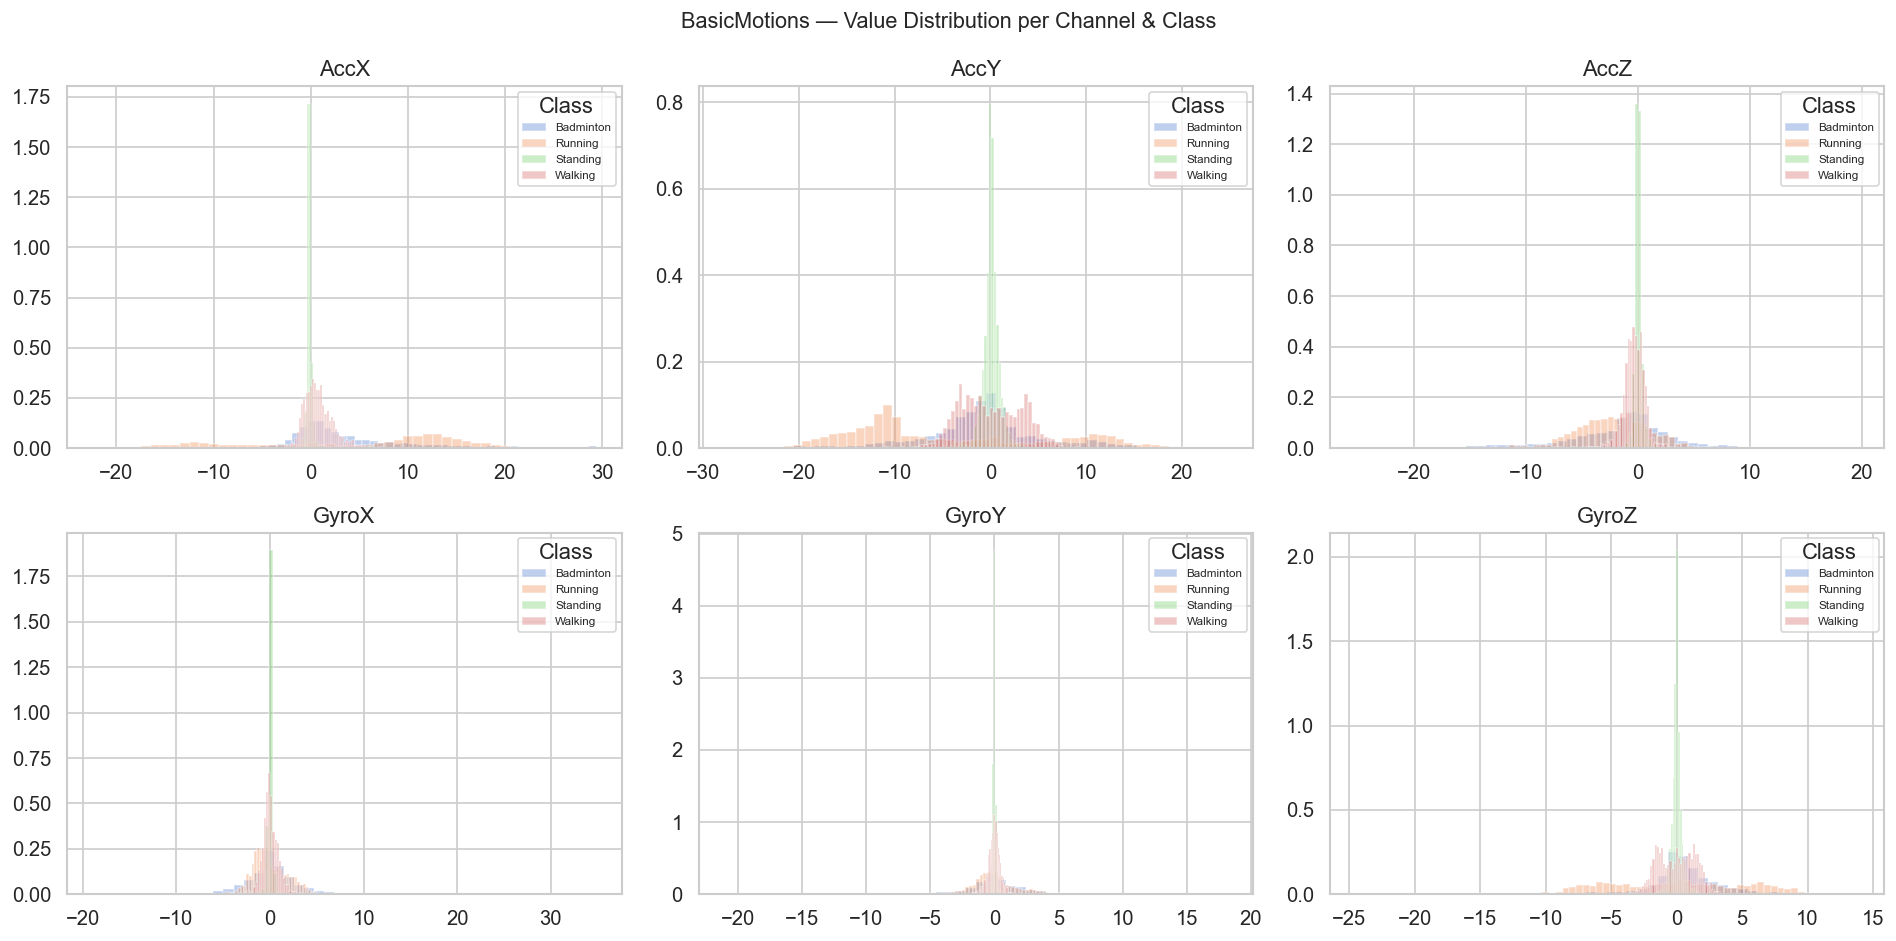

In [16]:
# ── 10a. BasicMotions — per-channel KDE coloured by class ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ch in range(6):
    ax = axes[ch]
    for cls in np.unique(y_bm):
        mask = y_bm == cls
        vals = X_bm[mask, :, ch].flatten()
        # subsample for speed
        vals = np.random.default_rng(42).choice(vals, min(2000, len(vals)), replace=False)
        ax.hist(vals, bins=50, density=True, alpha=0.35, label=str(cls))
    ax.set_title(BM_CH[ch])
    ax.legend(fontsize=7, title="Class")

fig.suptitle("BasicMotions — Value Distribution per Channel & Class", fontsize=13)
plt.tight_layout()
plt.show()

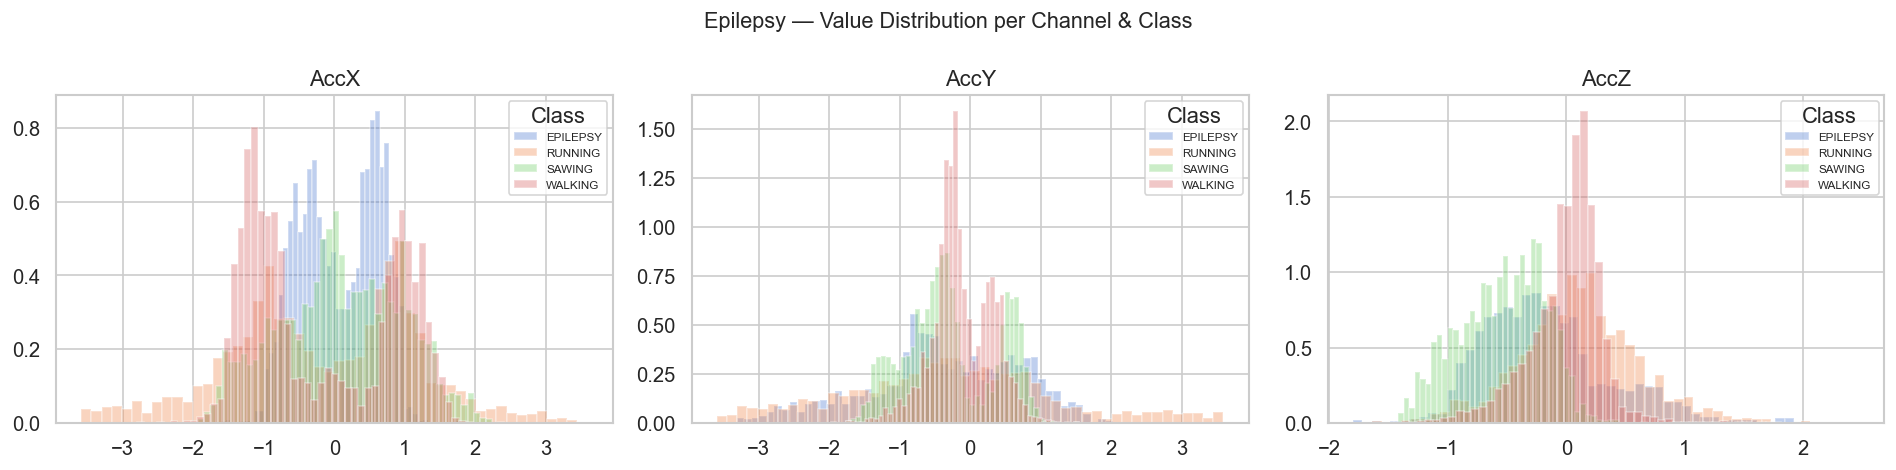

In [17]:
# ── 10b. Epilepsy — per-channel KDE coloured by class ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ch in range(3):
    ax = axes[ch]
    for cls in np.unique(y_ep):
        mask = y_ep == cls
        vals = X_ep[mask, :, ch].flatten()
        vals = np.random.default_rng(42).choice(vals, min(3000, len(vals)), replace=False)
        ax.hist(vals, bins=50, density=True, alpha=0.35, label=str(cls))
    ax.set_title(EP_CH[ch])
    ax.legend(fontsize=7, title="Class")

fig.suptitle("Epilepsy — Value Distribution per Channel & Class", fontsize=13)
plt.tight_layout()
plt.show()

## 11. DSA — Subject Variability

Since DSA uses Leave-One-Subject-Out CV, it's important to understand inter-subject variability. We plot mean channel values per subject to see how much the signal changes across participants.

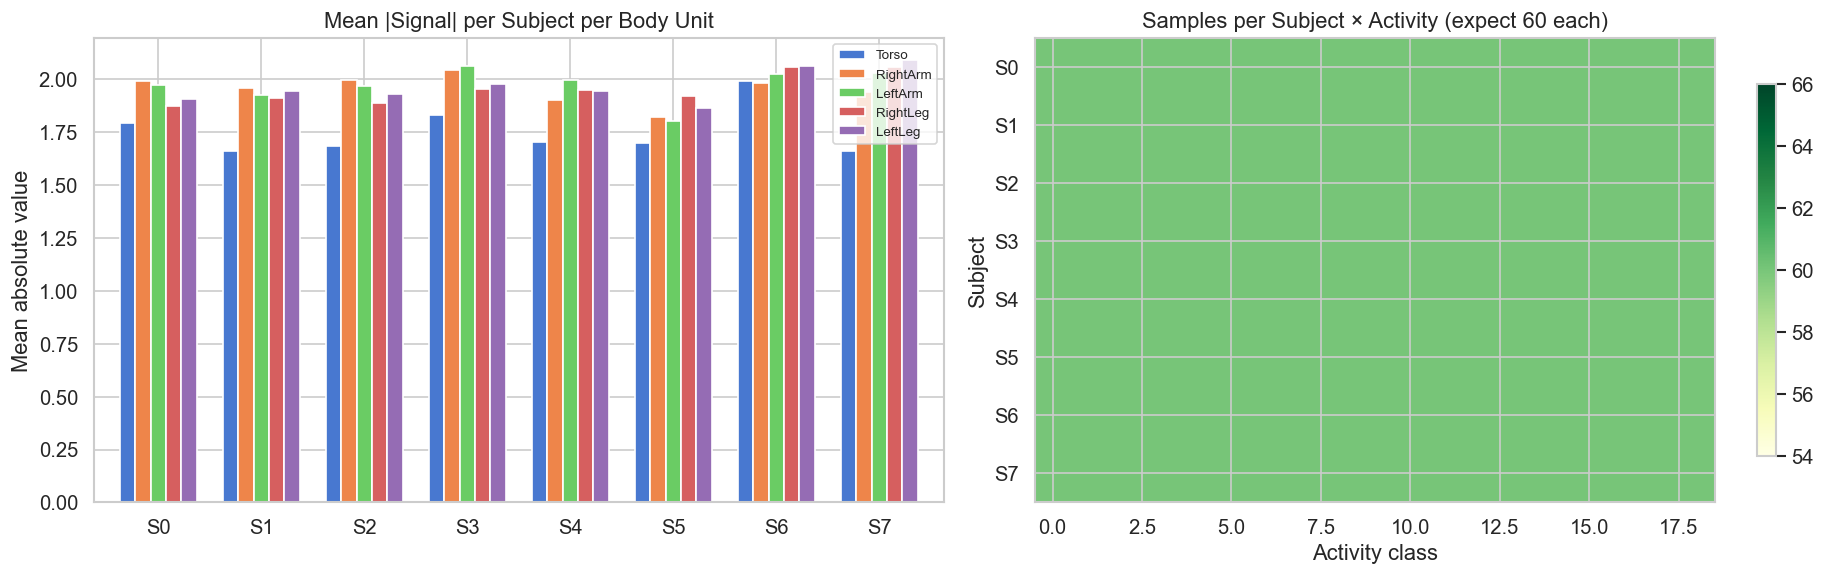

Samples per subject: {'S0': 1140, 'S1': 1140, 'S2': 1140, 'S3': 1140, 'S4': 1140, 'S5': 1140, 'S6': 1140, 'S7': 1140}


In [18]:
# ── 11. DSA subject variability ───────────────────────────────────────────────
subjects = dsa["subjects"]
unique_subjs = np.unique(subjects)

# Mean signal magnitude per subject (across all channels and timesteps)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# a) Mean absolute value per subject per body unit
unit_means = np.zeros((len(unique_subjs), 5))
for si, s in enumerate(unique_subjs):
    mask = subjects == s
    X_s = X_dsa[mask]  # (N_s, 125, 45)
    for u in range(5):
        unit_means[si, u] = np.mean(np.abs(X_s[:, :, u*9:(u+1)*9]))

df_subj = pd.DataFrame(unit_means, columns=DSA_UNITS, index=[f"S{int(s)}" for s in unique_subjs])
df_subj.plot(kind="bar", ax=axes[0], width=0.75)
axes[0].set_title("Mean |Signal| per Subject per Body Unit")
axes[0].set_ylabel("Mean absolute value")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

# b) Class distribution per subject (should be perfectly balanced: 60 per class)
subj_cls = np.zeros((len(unique_subjs), 19), dtype=int)
for si, s in enumerate(unique_subjs):
    mask = subjects == s
    for cls in range(19):
        subj_cls[si, cls] = int((y_dsa[mask] == cls).sum())
axes[1].imshow(subj_cls, aspect="auto", cmap="YlGn")
axes[1].set_xlabel("Activity class")
axes[1].set_ylabel("Subject")
axes[1].set_yticks(range(len(unique_subjs)))
axes[1].set_yticklabels([f"S{int(s)}" for s in unique_subjs])
axes[1].set_title("Samples per Subject × Activity (expect 60 each)")
plt.colorbar(axes[1].images[0], ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print("Samples per subject:", {f"S{int(s)}": int((subjects == s).sum()) for s in unique_subjs})

## 12. Dimensionality Reduction — t-SNE / PCA

Flatten each sample into a feature vector and project to 2D. This reveals whether classes form separable clusters in the raw feature space — a useful baseline before training any model.

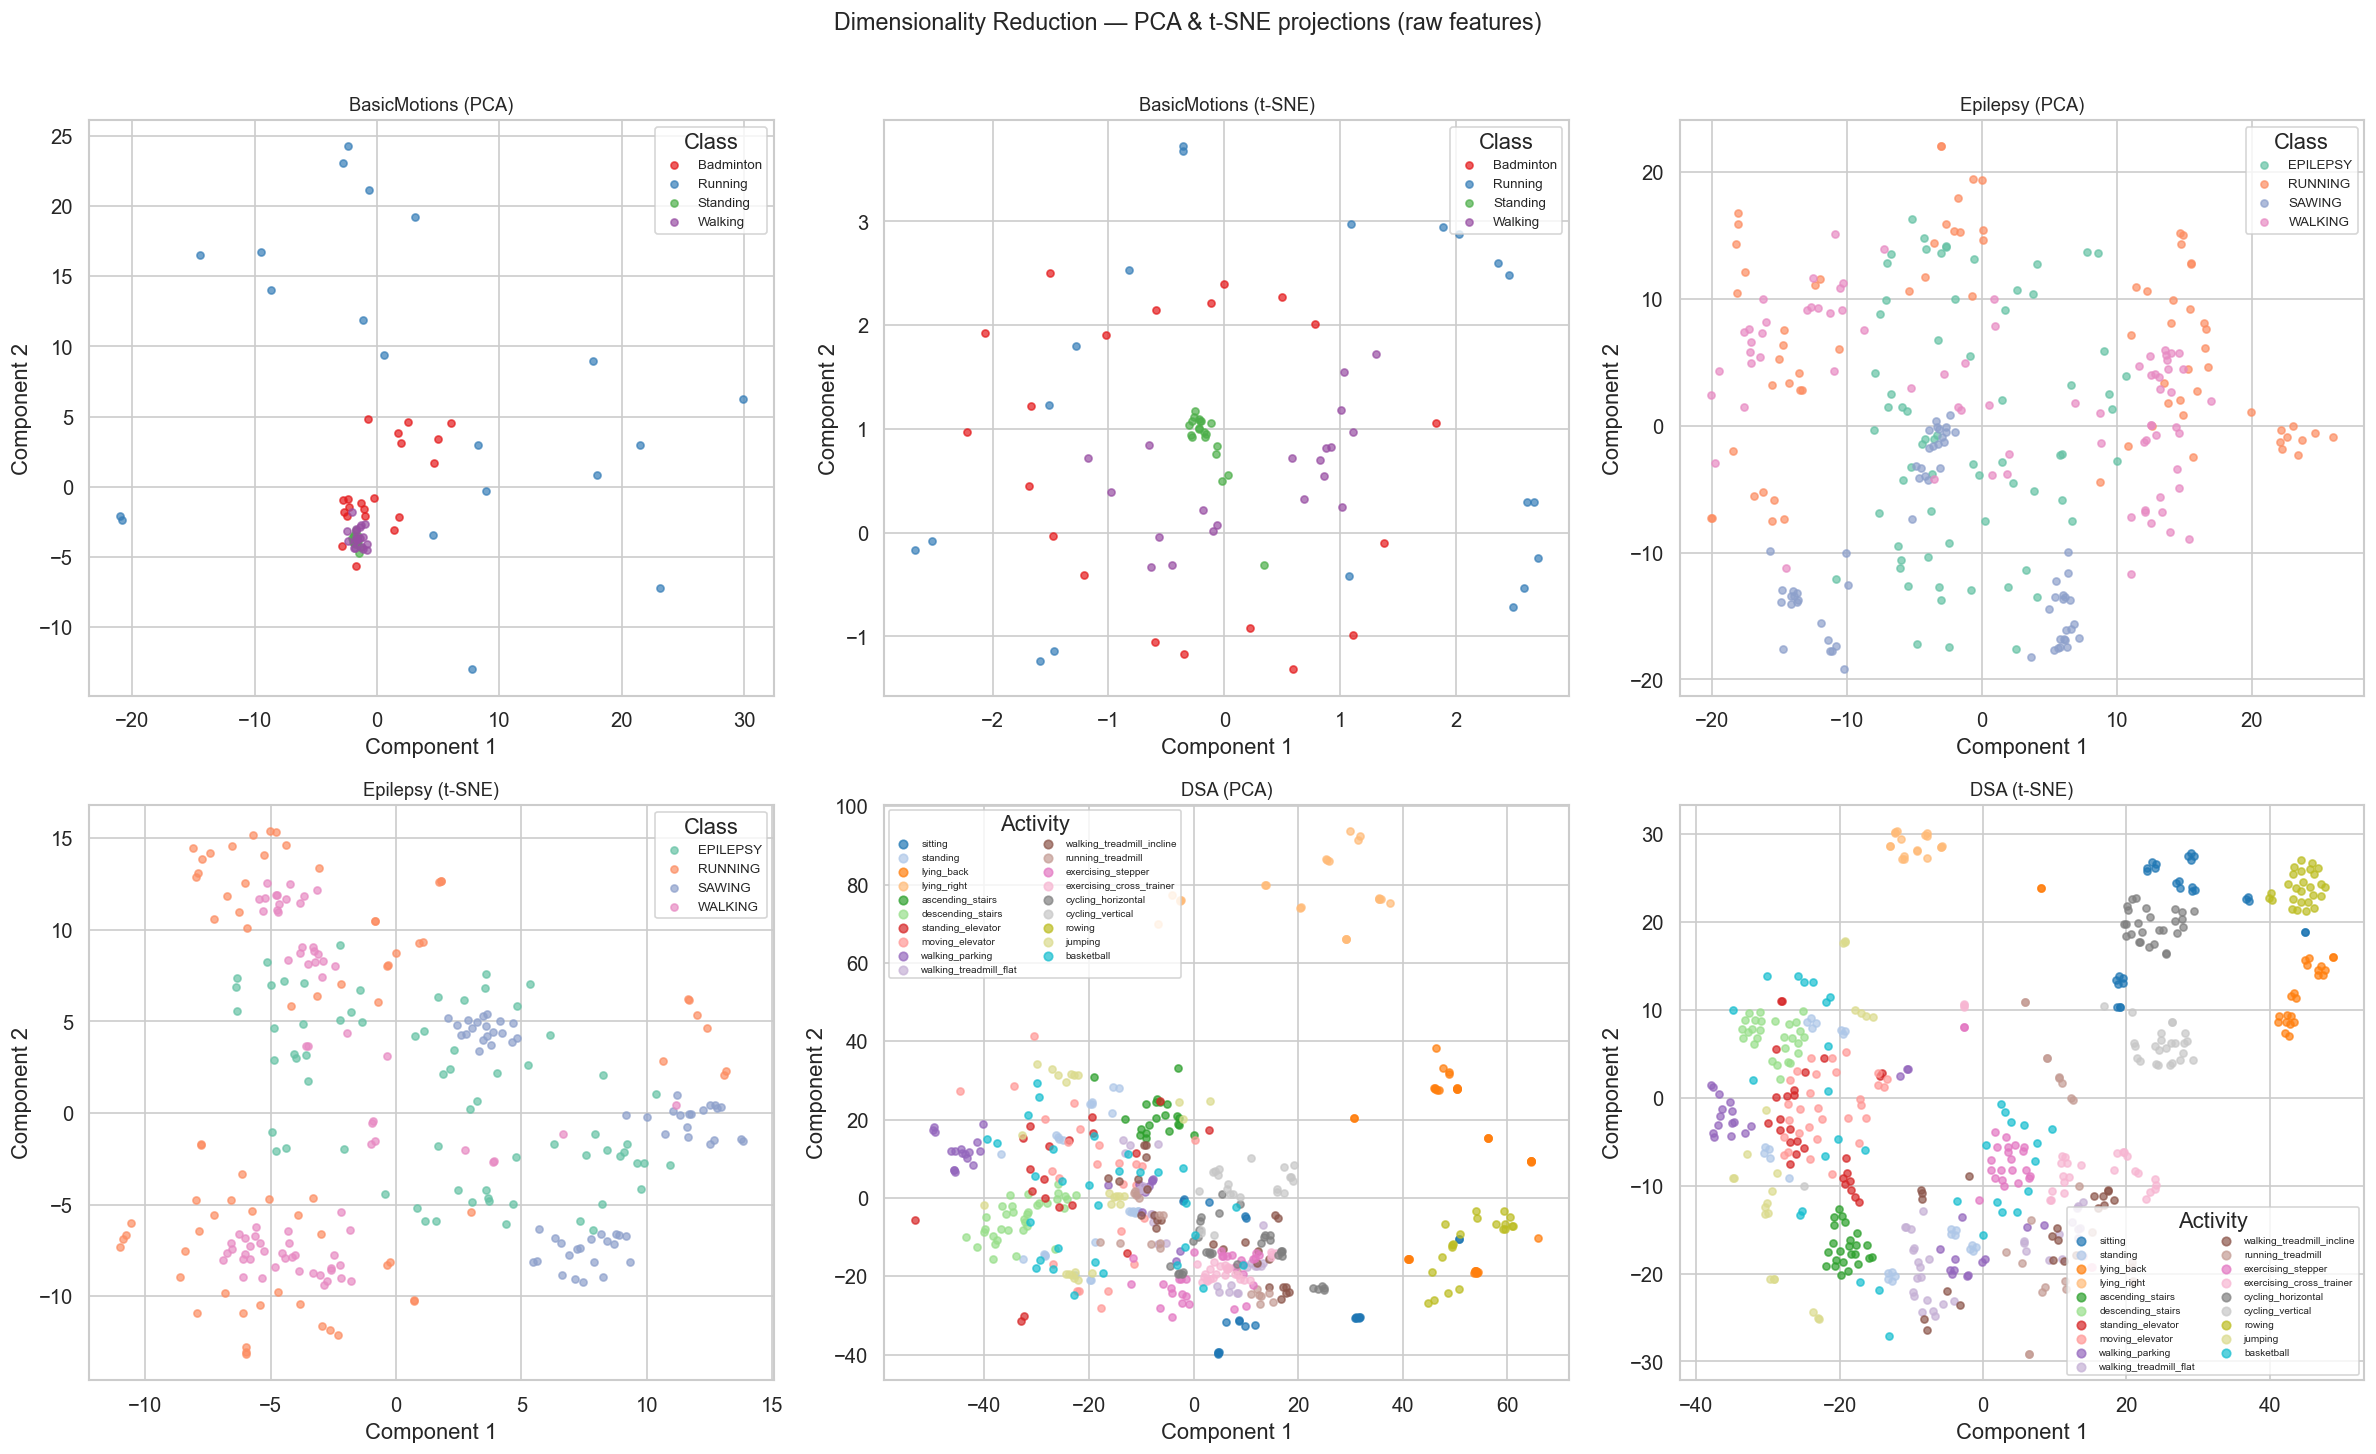


Variance explained by first 2 PCs:
  BasicMotions   : PC1=8.9%  PC2=8.4%  Total=17.4%
  Epilepsy       : PC1=20.5%  PC2=15.3%  Total=35.8%


  DSA            : PC1=11.9%  PC2=10.4%  Total=22.3%


In [19]:
# ── 12. Dimensionality Reduction — PCA + t-SNE ──────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

def reduce_2d(X, y, method="tsne", n_components=2, max_samples=500, seed=42):
    """Flatten samples, optionally subsample, then reduce to 2D."""
    N = X.shape[0]
    flat = X.reshape(N, -1)
    flat = StandardScaler().fit_transform(flat)
    if N > max_samples:
        idx = rng.choice(N, max_samples, replace=False)
        flat, y = flat[idx], y[idx]
    if method == "pca":
        reducer = PCA(n_components=n_components, random_state=seed)
    else:
        # PCA pre-reduction, then t-SNE with method='exact' to avoid
        # a threadpoolctl/OpenBLAS incompatibility in the knn-based code path
        n_pre = min(50, flat.shape[1])
        flat = PCA(n_components=n_pre, random_state=seed).fit_transform(flat)
        reducer = TSNE(n_components=n_components, perplexity=30, random_state=seed,
                       n_iter=1000, init="pca", method="exact")
    emb = reducer.fit_transform(flat)
    return emb, y

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

datasets = [
    ("BasicMotions (PCA)",   X_bm,  y_bm,  "pca"),
    ("BasicMotions (t-SNE)", X_bm,  y_bm,  "tsne"),
    ("Epilepsy (PCA)",       X_ep,  y_ep,  "pca"),
    ("Epilepsy (t-SNE)",     X_ep,  y_ep,  "tsne"),
    ("DSA (PCA)",            X_dsa, y_dsa, "pca"),
    ("DSA (t-SNE)",          X_dsa, y_dsa, "tsne"),
]

palettes = {
    "BasicMotions": sns.color_palette("Set1", 4),
    "Epilepsy":     sns.color_palette("Set2", 4),
    "DSA":          sns.color_palette("tab20", 19),
}

for ax, (title, X, y, method) in zip(axes.flatten(), datasets):
    emb, ys = reduce_2d(X, y, method=method)
    ds_key = title.split()[0]
    pal = palettes[ds_key]
    unique_cls = sorted(np.unique(ys))
    for ci, cls in enumerate(unique_cls):
        mask = ys == cls
        label = DSA_ACTIVITIES[cls] if ds_key == "DSA" and cls < len(DSA_ACTIVITIES) else str(cls)
        ax.scatter(emb[mask, 0], emb[mask, 1], s=18, alpha=0.7,
                   color=pal[ci % len(pal)], label=label)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    if ds_key != "DSA":
        ax.legend(fontsize=8, title="Class", loc="best")
    else:
        ax.legend(fontsize=6, title="Activity", loc="best",
                  ncol=2, markerscale=1.2)

fig.suptitle("Dimensionality Reduction — PCA & t-SNE projections (raw features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Variance explained by first 2 PCs
print("\nVariance explained by first 2 PCs:")
for name, X in [("BasicMotions", X_bm), ("Epilepsy", X_ep), ("DSA", X_dsa)]:
    N = X.shape[0]
    flat = StandardScaler().fit_transform(X.reshape(N, -1))
    pca = PCA(n_components=2, random_state=42).fit(flat)
    print(f"  {name:15s}: PC1={pca.explained_variance_ratio_[0]:.1%}  "
          f"PC2={pca.explained_variance_ratio_[1]:.1%}  "
          f"Total={sum(pca.explained_variance_ratio_):.1%}")


## 13. TGNN Graph Construction — Predefined Adjacency Structures

Each sensor channel is treated as a **graph node**. An edge between two nodes means the model shares information between those channels at every timestep via graph convolution.

Three predefined graph strategies are used in the thesis:

| Dataset | Graph | Nodes | Edges (undirected) | Rationale |
|---------|-------|-------|--------------------|-----------|
| BasicMotions | Sensor-axis | 6 | 9 | Intra-acc + intra-gyro + cross-axis same direction |
| Epilepsy | Fully connected | 3 | 3 | All tri-axial acc axes share the same sensor |
| DSA (coarse) | Anatomical body-segment | 5 | 6 | Torso↔limbs + bilateral symmetry |
| DSA (fine) | Channel-level | 45 | ~180 | Intra-unit full + inter-unit matching channels |

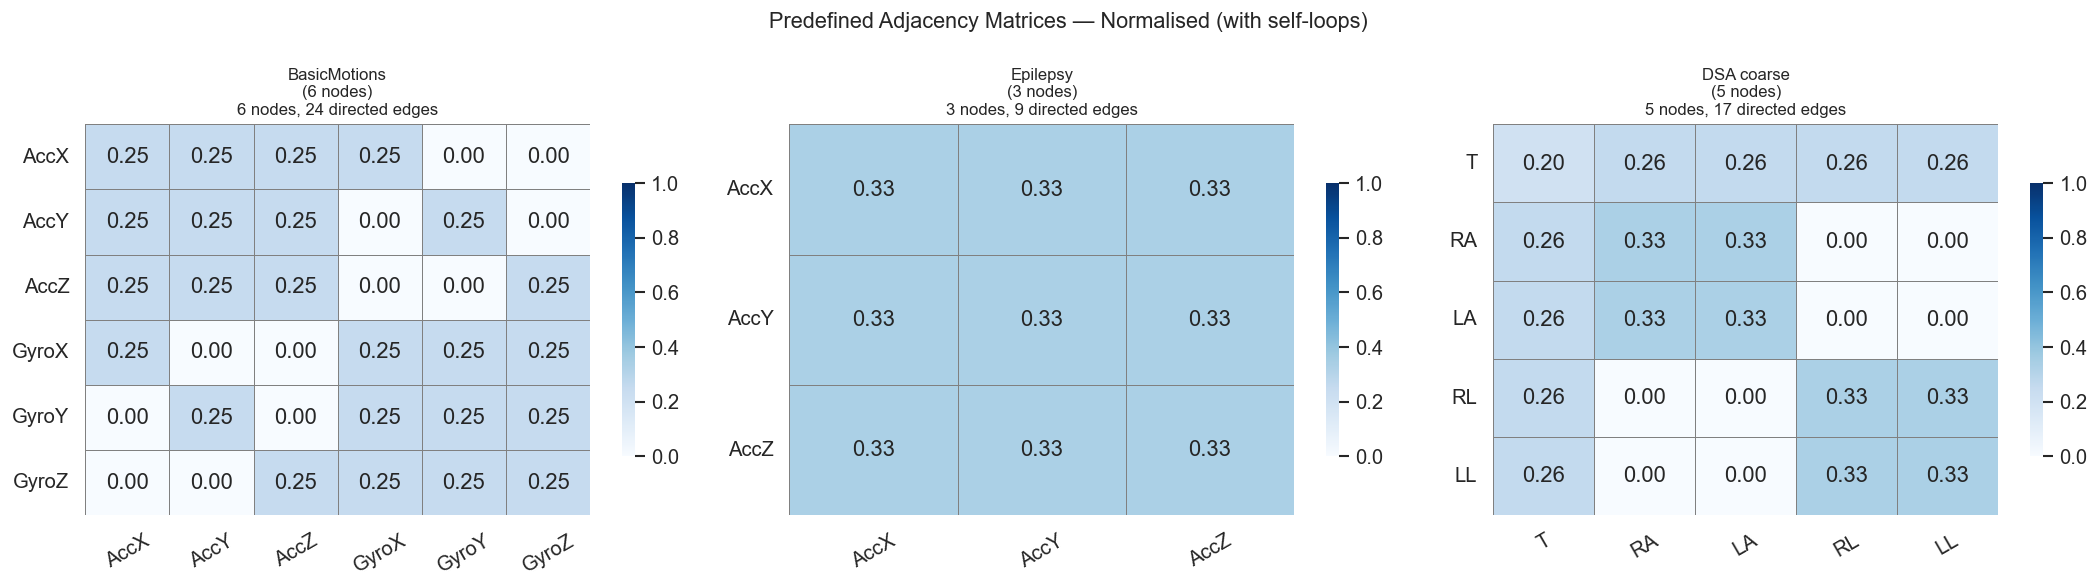


Graph summary:
Dataset                 Nodes   Directed edges    Density
----------------------------------------------------------
BasicMotions (6 nodes)      6               24     66.67%
Epilepsy (3 nodes)          3                9    100.00%
DSA coarse (5 nodes)        5               17     68.00%
DSA fine (45 nodes)        45              513     25.33%


In [20]:
# ── 13. Predefined adjacency matrices ───────────────────────────────────────
import sys, os
sys.path.insert(0, ROOT)
from src.graphs.predefined import build_predefined_graph

BM_NODES  = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
EP_NODES  = ["AccX", "AccY", "AccZ"]
DSA_COARSE_NODES = ["Torso", "RightArm", "LeftArm", "RightLeg", "LeftLeg"]
DSA_SHORT = ["T", "RA", "LA", "RL", "LL"]

graphs = {
    "BasicMotions\n(6 nodes)":  build_predefined_graph("BasicMotions"),
    "Epilepsy\n(3 nodes)":      build_predefined_graph("Epilepsy"),
    "DSA coarse\n(5 nodes)":    build_predefined_graph("DSA", granularity="coarse"),
}
node_labels = {
    "BasicMotions\n(6 nodes)":  BM_NODES,
    "Epilepsy\n(3 nodes)":      EP_NODES,
    "DSA coarse\n(5 nodes)":    DSA_SHORT,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, g) in zip(axes, graphs.items()):
    adj = g["adj_matrix"].numpy() if hasattr(g["adj_matrix"], "numpy") else np.array(g["adj_matrix"])
    labs = node_labels[title]
    n = len(labs)
    sns.heatmap(adj, ax=ax, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labs, yticklabels=labs, vmin=0, vmax=1,
                linewidths=0.5, linecolor="grey", cbar_kws={"shrink": 0.7})
    ax.set_title(f"{title}\n{g['num_nodes']} nodes, "
                 f"{int(g['edge_index'].shape[1])} directed edges",
                 fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Predefined Adjacency Matrices — Normalised (with self-loops)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nGraph summary:")
print(f"{'Dataset':<22} {'Nodes':>6} {'Directed edges':>16} {'Density':>10}")
print("-" * 58)
for title, g in graphs.items():
    name = title.replace("\n", " ")
    n = g["num_nodes"]
    e = g["edge_index"].shape[1]
    density = e / (n * n)
    print(f"{name:<22} {n:>6} {e:>16} {density:>10.2%}")

# Fine-grained DSA graph for reference
g_fine = build_predefined_graph("DSA", granularity="fine")
n, e = g_fine["num_nodes"], g_fine["edge_index"].shape[1]
print(f"{'DSA fine (45 nodes)':<22} {n:>6} {e:>16} {e/(n*n):>10.2%}")


## 14. Graph Alignment — Do Predefined Edges Match Empirical Correlations?

We overlay the predefined graph edges onto the correlation matrices computed in Section 8.
High empirical correlation between two channels that share a graph edge validates the
domain-knowledge design. Pairs connected by an edge but with low correlation would
suggest the adaptive (learned) graph might find a better topology.

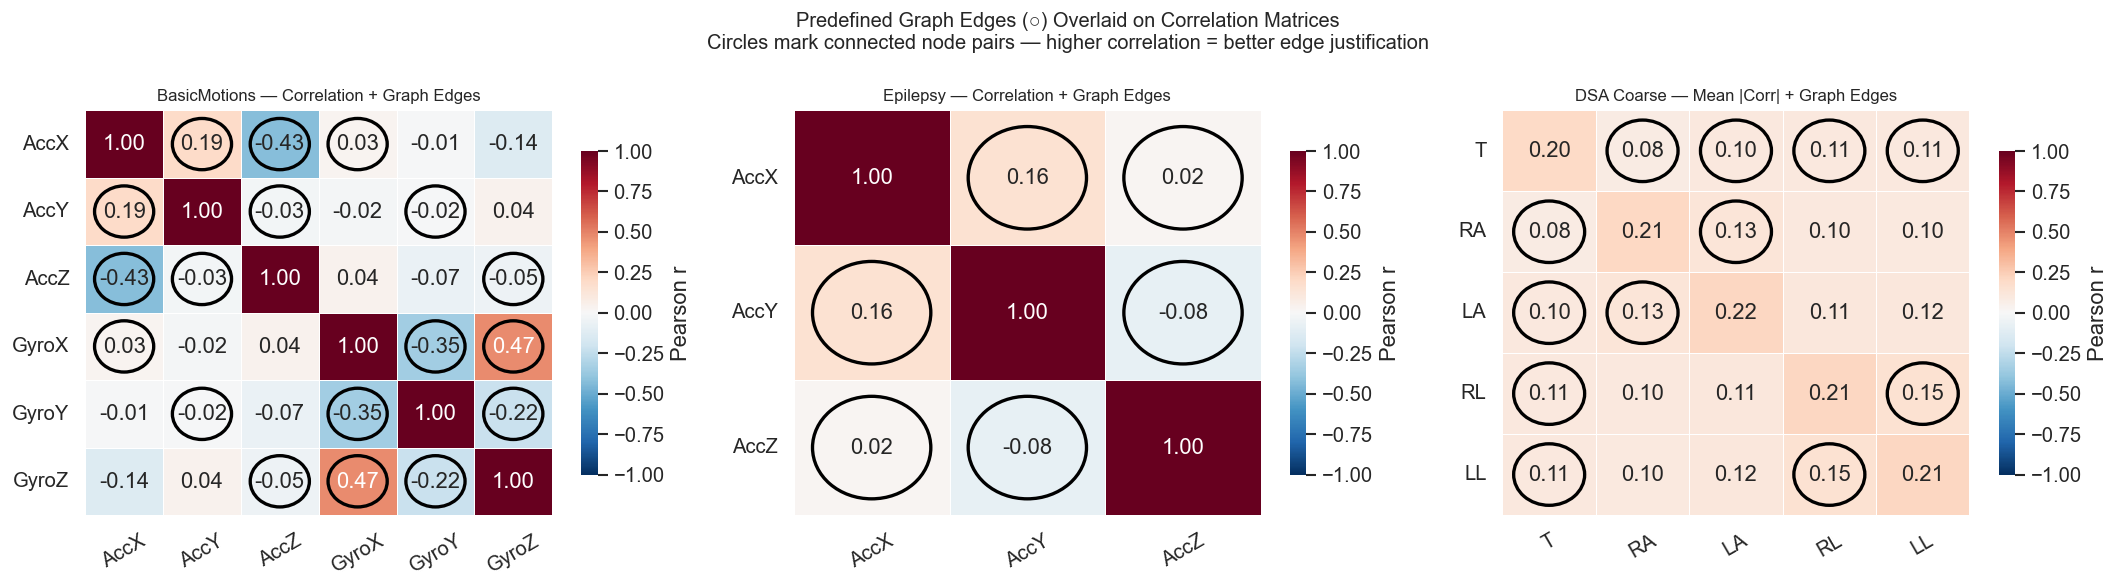

Edge-correlation alignment:
Dataset                Edges mean |r|   Non-edges mean |r|     Lift
--------------------------------------------------------------------
BasicMotions                    0.199                0.054     3.66x
Epilepsy                        0.084                0.000      infx
DSA coarse                      0.113                0.109     1.04x


In [21]:
# ── 14. Graph alignment — correlation vs. graph edges ───────────────────────
def plot_corr_with_edges(ax, corr_matrix, adj_matrix, node_names, title):
    """Annotated correlation heatmap with circles marking graph edges."""
    n = len(node_names)
    adj = adj_matrix.numpy() if hasattr(adj_matrix, "numpy") else np.array(adj_matrix)
    sns.heatmap(corr_matrix, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
                xticklabels=node_names, yticklabels=node_names,
                vmin=-1, vmax=1, center=0, linewidths=0.4,
                cbar_kws={"shrink": 0.8, "label": "Pearson r"})
    # Mark predefined edges with a bold circle
    for i in range(n):
        for j in range(n):
            if i != j and adj[i, j] > 0:
                ax.add_patch(plt.Circle(
                    (j + 0.5, i + 0.5), 0.38,
                    fill=False, edgecolor="black", linewidth=2.0, zorder=5
                ))
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BasicMotions
g_bm = build_predefined_graph("BasicMotions")
plot_corr_with_edges(axes[0], corr_bm, g_bm["adj_matrix"], BM_NODES,
                     "BasicMotions — Correlation + Graph Edges")

# Epilepsy
g_ep = build_predefined_graph("Epilepsy")
plot_corr_with_edges(axes[1], corr_ep, g_ep["adj_matrix"], EP_NODES,
                     "Epilepsy — Correlation + Graph Edges")

# DSA coarse (5×5 mean-abs correlation)
g_dsa = build_predefined_graph("DSA", granularity="coarse")
plot_corr_with_edges(axes[2], coarse, g_dsa["adj_matrix"], DSA_SHORT,
                     "DSA Coarse — Mean |Corr| + Graph Edges")

fig.suptitle("Predefined Graph Edges (○) Overlaid on Correlation Matrices\n"
             "Circles mark connected node pairs — higher correlation = better edge justification",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Quantitative alignment ────────────────────────────────────────────────────
print("Edge-correlation alignment:")
print(f"{'Dataset':<18} {'Edges mean |r|':>18} {'Non-edges mean |r|':>20} {'Lift':>8}")
print("-" * 68)
for dataset, corr, g in [
    ("BasicMotions", corr_bm, build_predefined_graph("BasicMotions")),
    ("Epilepsy",     corr_ep, build_predefined_graph("Epilepsy")),
    ("DSA coarse",   coarse,  build_predefined_graph("DSA", granularity="coarse")),
]:
    adj = g["adj_matrix"].numpy() if hasattr(g["adj_matrix"], "numpy") else np.array(g["adj_matrix"])
    abs_corr = np.abs(corr)
    n = adj.shape[0]
    mask_diag = ~np.eye(n, dtype=bool)
    edge_mask    = (adj > 0) & mask_diag
    non_edge_mask = (adj == 0) & mask_diag
    edge_mean    = abs_corr[edge_mask].mean()    if edge_mask.any()     else 0.0
    non_edge_mean = abs_corr[non_edge_mask].mean() if non_edge_mask.any() else 0.0
    lift = edge_mean / non_edge_mean if non_edge_mean > 0 else float("inf")
    print(f"{dataset:<18} {edge_mean:>18.3f} {non_edge_mean:>20.3f} {lift:>8.2f}x")


## 15. Temporal Structure — Autocorrelation & Spectral Analysis

The **temporal** component of a TGNN (LSTM / GRU / TCN cells) must capture patterns
whose timescale matches the signal's inherent periodicity.

- **Autocorrelation** tells us how many timesteps back are still predictive.
- **Power Spectral Density (FFT)** reveals the dominant frequency of each activity class.

If signals are periodic at 1–3 Hz and are sampled at 10–25 Hz with windows of 5–12 s,
the model sees at least 3–10 full cycles — providing sufficient temporal context.

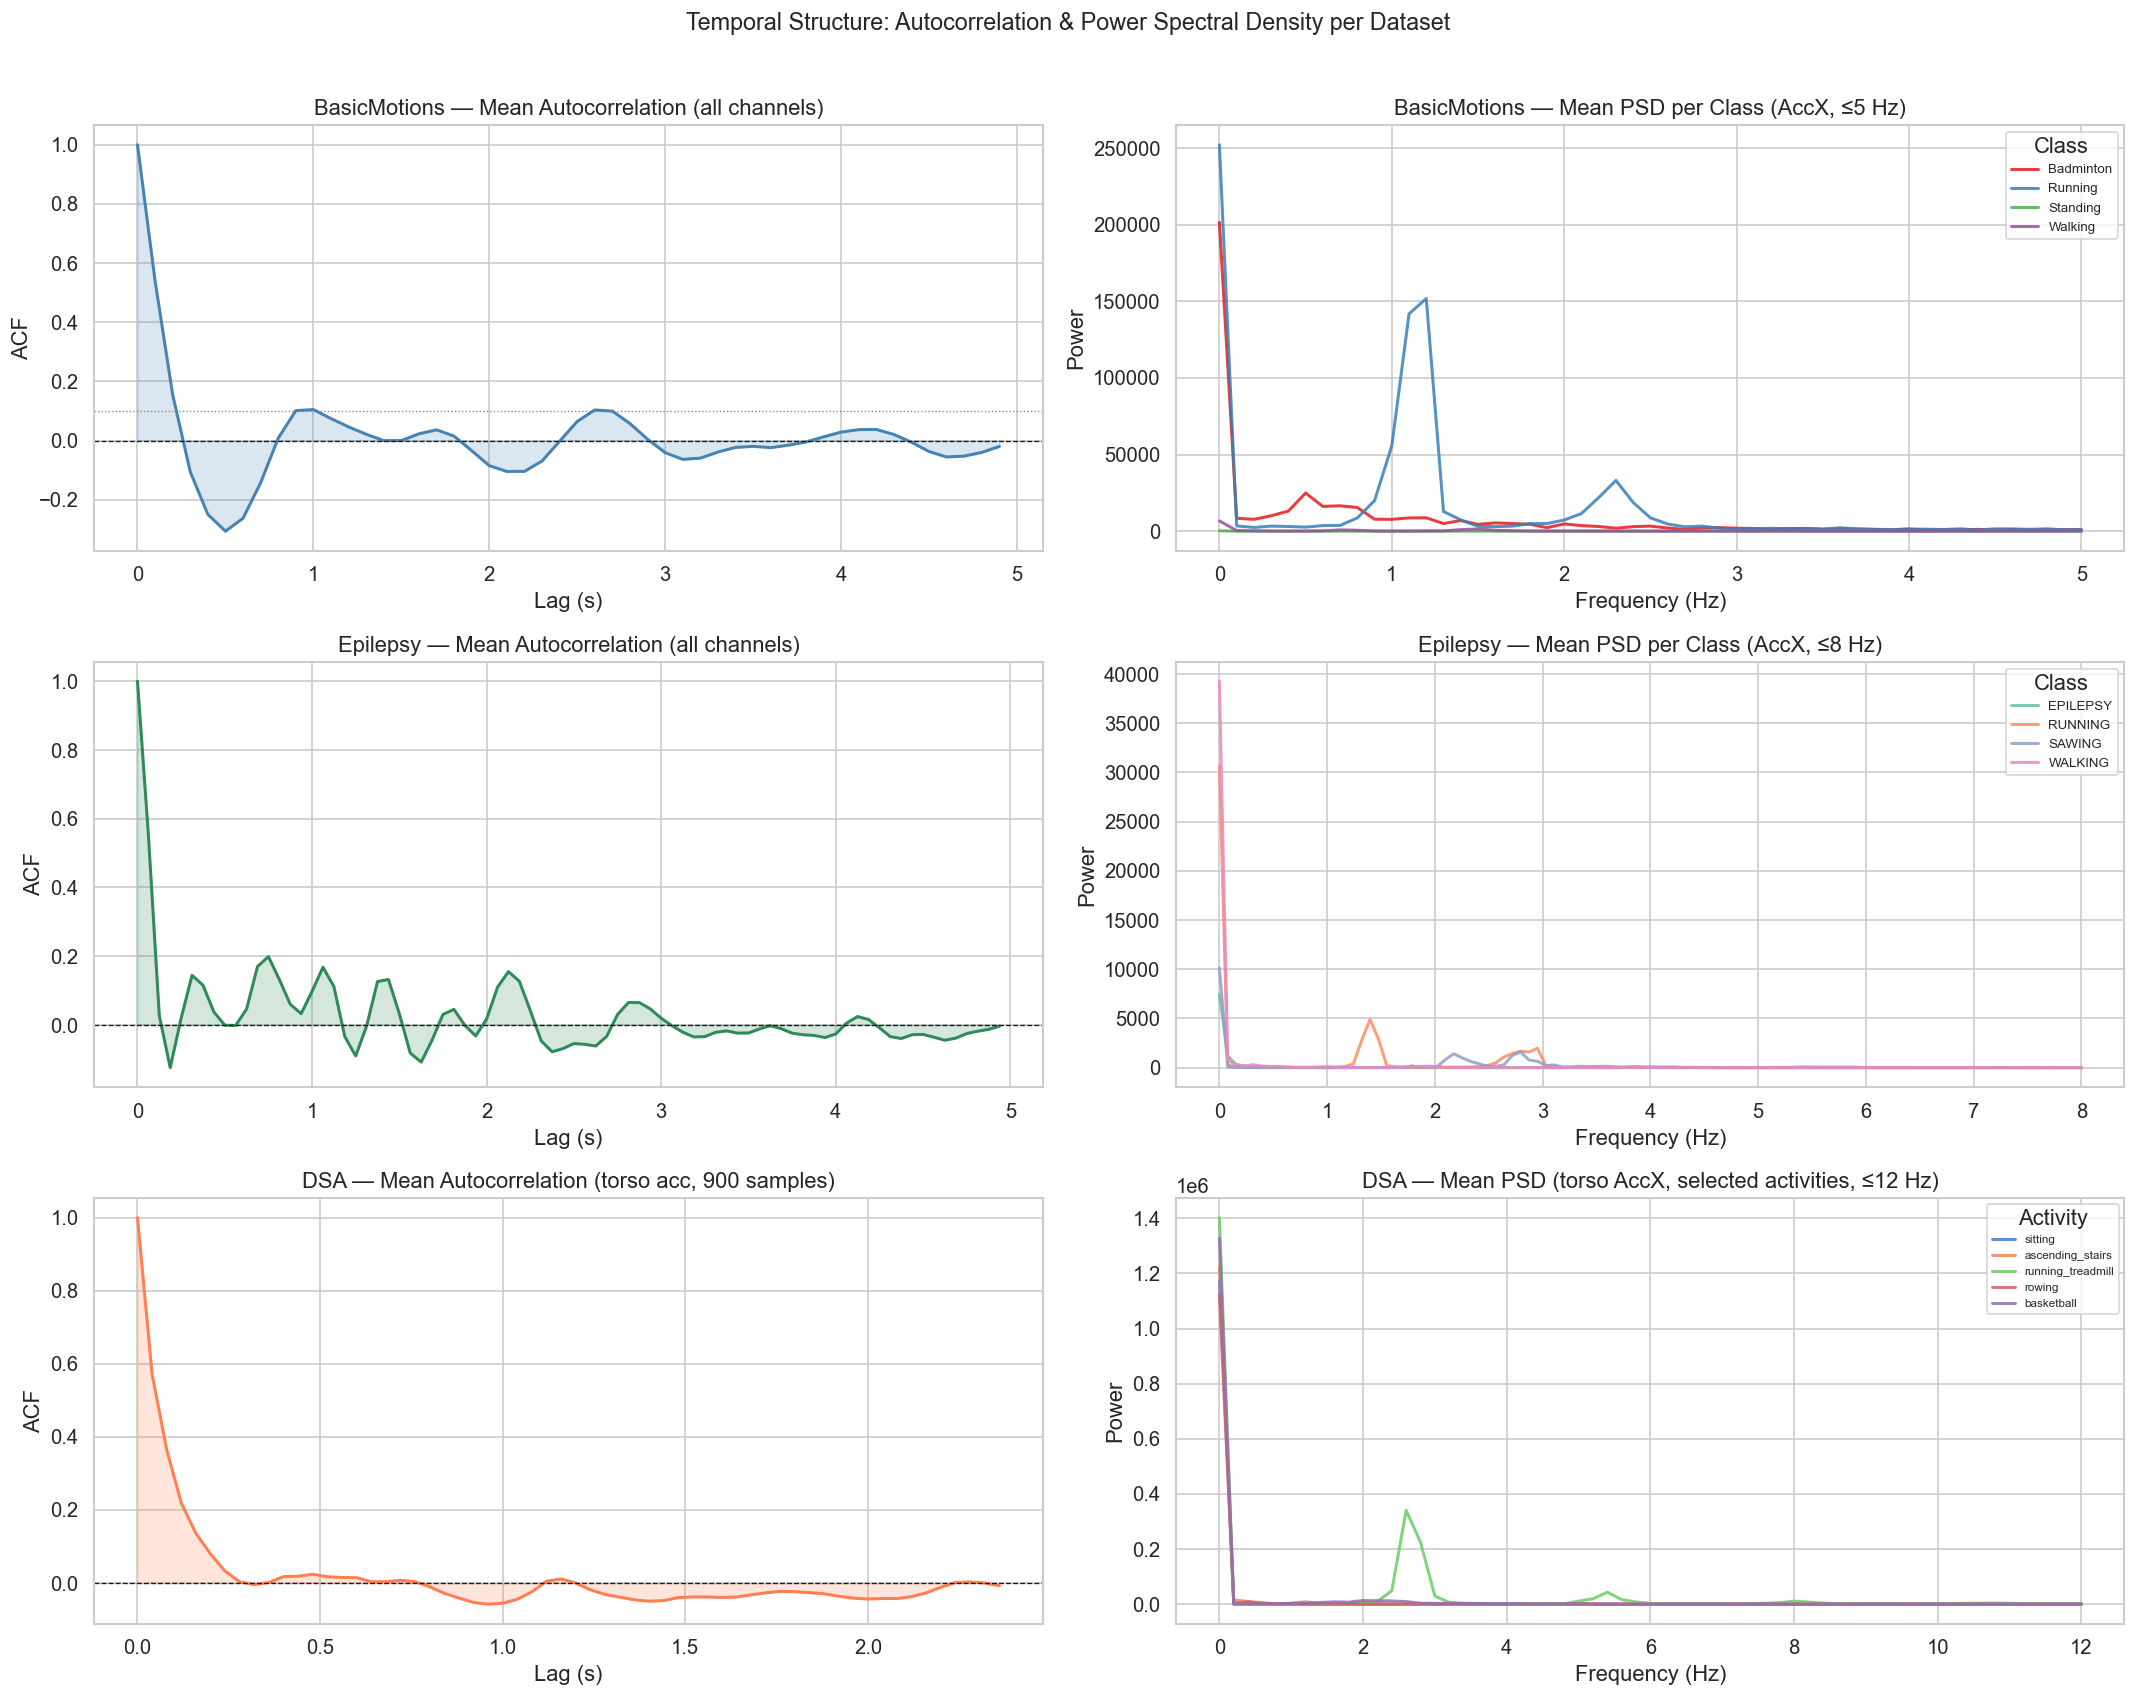


DSA — Dominant frequency per activity (torso AccX):
Activity                         Dom. freq (Hz)
--------------------------------------------------
sitting                                    0.40
standing                                   0.40
lying_back                                 0.40
lying_right                                0.40
ascending_stairs                           1.20
descending_stairs                          0.40
standing_elevator                          0.40
moving_elevator                            1.60
walking_parking                            1.60
walking_treadmill_flat                     1.80
walking_treadmill_incline                  1.80
running_treadmill                          2.60
exercising_stepper                         1.40
exercising_cross_trainer                   2.00
cycling_horizontal                         4.40
cycling_vertical                           2.20
rowing                                     0.40
jumping                         

In [22]:
# ── 15. Autocorrelation & Spectral analysis ──────────────────────────────────
def mean_acf(X, n_lags):
    """Mean autocorrelation across all samples and channels."""
    acf = np.zeros(n_lags)
    N, T, C = X.shape
    count = N * C
    for n in range(N):
        for c in range(C):
            s = X[n, :, c]
            s = s - s.mean()
            norm = np.dot(s, s)
            if norm == 0:
                count -= 1
                continue
            for lag in range(n_lags):
                acf[lag] += np.dot(s[:T-lag], s[lag:]) / norm
    return acf / max(count, 1)

def mean_psd_by_class(X, y, fs, n_fft=None):
    """Mean PSD per class (average over all samples and channels, first channel only for speed)."""
    classes = sorted(np.unique(y))
    freq = np.fft.rfftfreq(X.shape[1], d=1.0/fs)
    psd_dict = {}
    for cls in classes:
        idx = np.where(y == cls)[0]
        segs = X[idx, :, 0]   # first channel only
        psds = np.abs(np.fft.rfft(segs, n=n_fft, axis=1)) ** 2
        psd_dict[cls] = psds.mean(axis=0)
    return freq, psd_dict

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# ── Row 0: BasicMotions ────────────────────────────────────────────────────────
n_lags_bm = 50
lags_bm = np.arange(n_lags_bm) / 10.0   # seconds at 10 Hz
acf_bm   = mean_acf(X_bm, n_lags_bm)
axes[0, 0].plot(lags_bm, acf_bm, color="steelblue", linewidth=1.8)
axes[0, 0].axhline(0, color="k", linewidth=0.8, linestyle="--")
axes[0, 0].axhline(0.1, color="grey", linewidth=0.8, linestyle=":")
axes[0, 0].fill_between(lags_bm, acf_bm, 0, alpha=0.2, color="steelblue")
axes[0, 0].set_title("BasicMotions — Mean Autocorrelation (all channels)")
axes[0, 0].set_xlabel("Lag (s)")
axes[0, 0].set_ylabel("ACF")

freq_bm, psd_bm = mean_psd_by_class(X_bm, y_bm, fs=10)
pal_bm = sns.color_palette("Set1", 4)
for i, (cls, psd) in enumerate(psd_bm.items()):
    f_mask = freq_bm <= 5.0
    axes[0, 1].plot(freq_bm[f_mask], psd[f_mask], label=str(cls),
                    color=pal_bm[i], linewidth=1.8, alpha=0.85)
axes[0, 1].set_title("BasicMotions — Mean PSD per Class (AccX, ≤5 Hz)")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Power")
axes[0, 1].legend(title="Class", fontsize=8)

# ── Row 1: Epilepsy ────────────────────────────────────────────────────────────
n_lags_ep = 80
lags_ep = np.arange(n_lags_ep) / 16.0
acf_ep   = mean_acf(X_ep, n_lags_ep)
axes[1, 0].plot(lags_ep, acf_ep, color="seagreen", linewidth=1.8)
axes[1, 0].axhline(0, color="k", linewidth=0.8, linestyle="--")
axes[1, 0].fill_between(lags_ep, acf_ep, 0, alpha=0.2, color="seagreen")
axes[1, 0].set_title("Epilepsy — Mean Autocorrelation (all channels)")
axes[1, 0].set_xlabel("Lag (s)")
axes[1, 0].set_ylabel("ACF")

freq_ep, psd_ep = mean_psd_by_class(X_ep, y_ep, fs=16)
pal_ep = sns.color_palette("Set2", 4)
for i, (cls, psd) in enumerate(psd_ep.items()):
    f_mask = freq_ep <= 8.0
    axes[1, 1].plot(freq_ep[f_mask], psd[f_mask], label=str(cls),
                    color=pal_ep[i], linewidth=1.8, alpha=0.85)
axes[1, 1].set_title("Epilepsy — Mean PSD per Class (AccX, ≤8 Hz)")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Power")
axes[1, 1].legend(title="Class", fontsize=8)

# ── Row 2: DSA (subsample for speed) ─────────────────────────────────────────
rng2 = np.random.default_rng(0)
dsa_sub_idx = rng2.choice(len(X_dsa), 900, replace=False)
X_dsa_sub = X_dsa[dsa_sub_idx]
y_dsa_sub = y_dsa[dsa_sub_idx]

n_lags_dsa = 60
lags_dsa = np.arange(n_lags_dsa) / 25.0
acf_dsa   = mean_acf(X_dsa_sub[:, :, :3], n_lags_dsa)  # torso acc only
axes[2, 0].plot(lags_dsa, acf_dsa, color="coral", linewidth=1.8)
axes[2, 0].axhline(0, color="k", linewidth=0.8, linestyle="--")
axes[2, 0].fill_between(lags_dsa, acf_dsa, 0, alpha=0.2, color="coral")
axes[2, 0].set_title("DSA — Mean Autocorrelation (torso acc, 900 samples)")
axes[2, 0].set_xlabel("Lag (s)")
axes[2, 0].set_ylabel("ACF")

freq_dsa, psd_dsa = mean_psd_by_class(X_dsa_sub, y_dsa_sub, fs=25)
pal_dsa = sns.color_palette("tab20", 19)
sel_activities = [0, 4, 11, 16, 18]  # sitting, stairs, running, rowing, basketball
for ci in sel_activities:
    if ci in psd_dsa:
        label = DSA_ACTIVITIES[ci] if ci < len(DSA_ACTIVITIES) else str(ci)
        f_mask = freq_dsa <= 12.0
        axes[2, 1].plot(freq_dsa[f_mask], psd_dsa[ci][f_mask], label=label,
                        linewidth=1.8, alpha=0.85)
axes[2, 1].set_title("DSA — Mean PSD (torso AccX, selected activities, ≤12 Hz)")
axes[2, 1].set_xlabel("Frequency (Hz)")
axes[2, 1].set_ylabel("Power")
axes[2, 1].legend(title="Activity", fontsize=7, loc="upper right")

fig.suptitle("Temporal Structure: Autocorrelation & Power Spectral Density per Dataset",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Print dominant frequency per DSA activity ────────────────────────────────
print("\nDSA — Dominant frequency per activity (torso AccX):")
freq_dsa_full, psd_dsa_full = mean_psd_by_class(X_dsa, y_dsa, fs=25)
print(f"{'Activity':<30} {'Dom. freq (Hz)':>16}")
print("-" * 50)
for cls in sorted(psd_dsa_full):
    label = DSA_ACTIVITIES[cls] if cls < len(DSA_ACTIVITIES) else str(cls)
    f_mask = freq_dsa_full > 0.3  # exclude DC
    dom_idx = np.argmax(psd_dsa_full[cls][f_mask])
    dom_f = freq_dsa_full[f_mask][dom_idx]
    print(f"{label:<30} {dom_f:>16.2f}")
